In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


In [2]:
import random
from collections import defaultdict
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import MeanAggregation, SumAggregation

from tqdm.auto import tqdm

from bcos.modules import BcosLinear
from bcosgnn.explain_edge_attr import explain as explain_edge_attr
import os
import shutil
from torch_geometric.data import InMemoryDataset
import tqdm

/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import torch
import os
from pathlib import Path
from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader

class ZincProcessedDataset(InMemoryDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        super().__init__(root, transform, pre_transform)
        
        # Explicitly constructing the path to ensure it is correct
        data_path = Path(self.processed_dir) / "data.pt"
        
        print(f"Loading data from: {data_path.resolve()}")
        
        try:
             # weights_only=False required for PyTorch 2.6+ for PyG Data objects
            self.data, self.slices = torch.load(data_path, weights_only=False)
        except TypeError: 
            # Fallback for older PyTorch versions
            self.data, self.slices = torch.load(data_path)

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return ['data.pt']

    def download(self):
        pass

    def process(self):
        pass

cwd = Path.cwd()
print(f"Current Working Directory: {cwd}")


if (cwd / "zinc_di_halo_benzene_data").exists():
    dataset_path = "zinc_di_halo_benzene_data"
elif (cwd / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data").exists():
    dataset_path = "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
else:

    potential_path = cwd / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
    dataset_path = str(potential_path)

print(f"Using dataset path: {dataset_path}")

try:
    dataset = ZincProcessedDataset(root=dataset_path)
    print(f"Dataset loaded: {len(dataset)} graphs")
    print(f"Number of features: {dataset.num_features}")
    print(f"Number of classes: {dataset.num_classes}")

    # Create DataLoader
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    print(f"DataLoader created with {len(loader)} batches")

except Exception as e:
    print(f"Error loading dataset: {e}")


Current Working Directory: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/multi_class_Zinc
Using dataset path: zinc_di_halo_benzene_data
Loading data from: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data/processed/data.pt
Dataset loaded: 9000 graphs
Number of features: 10
Number of classes: 9
DataLoader created with 282 batches


## Bcos Model Definition

In [24]:
class BCosGINE(nn.Module):
    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        *,
        hidden_dim: int = 128,
        num_layers: int = 4,
        num_classes: int = 9,
        b: float = 2.0,
        max_out: int = 1,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.lin_node = BcosLinear(node_dim, hidden_dim, b=b, max_out=max_out)
        self.lin_edge = BcosLinear(edge_dim, hidden_dim, b=b, max_out=max_out)
        
        # Pure B-cos GINE convolutions
        self.convs = nn.ModuleList([
            GINEConv(BcosLinear(hidden_dim, hidden_dim, b=b, max_out=max_out), train_eps=False)
            for _ in range(num_layers)
        ])
        
        # Removed self.norms (Standard BatchNorm1d)
        
        self.agg = SumAggregation()
        self.dropout = nn.Dropout(dropout)
        self.head = BcosLinear(hidden_dim, num_classes, b=b, max_out=max_out)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        x = self.lin_node(x)
        edge_attr = self.lin_edge(edge_attr)
        
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)
            # Removed bn(x)
            # Removed F.relu(x)
            
        g = self.agg(x, batch)
        g = self.dropout(g)
        return self.head(g)  # [num_graphs, num_classes]

In [6]:
import time
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def _infer_num_classes(ds) -> int:
    ys = torch.tensor([ds[i].y.item() for i in range(len(ds))], dtype=torch.long)
    return int(torch.unique(ys).numel())


def make_splits_indices(y: np.ndarray, seed: int, test_size: float, k_folds: int):
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    (trainval_idx, test_idx) = next(splitter.split(np.zeros_like(y), y))
    y_trainval = y[trainval_idx]
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
    folds = []
    for fold_train_rel, fold_val_rel in skf.split(np.zeros_like(y_trainval), y_trainval):
        fold_train_idx = trainval_idx[fold_train_rel]
        fold_val_idx = trainval_idx[fold_val_rel]
        folds.append((fold_train_idx, fold_val_idx))
    return trainval_idx, test_idx, folds

In [7]:
def train_one_run_bcos(
    dataset,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    test_idx: np.ndarray,
    *,
    seed: int,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
    device=None,
    b: float = 2.0,
    max_out: int = 1,
    dropout: float = 0.5,
 ):
    set_seed(seed)
    device = device or get_device()

    sample = dataset[0]
    node_dim = int(sample.x.size(-1))
    edge_dim = int(sample.edge_attr.size(-1))
    num_classes = _infer_num_classes(dataset)

    model = BCosGINE(
        node_dim=node_dim,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        num_layers=4,
        num_classes=num_classes,
        b=b,
        max_out=max_out,
        dropout=dropout,
    ).to(device)

    train_loader = DataLoader(dataset.index_select(torch.tensor(train_idx)), batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(dataset.index_select(torch.tensor(val_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(dataset.index_select(torch.tensor(test_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience, min_lr=min_lr
    )

    best_state = None
    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_no_improve = 0

    def run_loader(loader, train: bool):
        if train:
            model.train()
        else:
            model.eval()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            y = batch.y.view(-1).to(device)
            loss = F.cross_entropy(logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            total_correct += (logits.argmax(dim=-1) == y).sum().item()
            total_examples += y.size(0)
        avg_loss = total_loss / max(1, total_examples)
        avg_acc = total_correct / max(1, total_examples)
        return avg_loss, avg_acc

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = run_loader(train_loader, train=True)
        val_loss, val_acc = run_loader(val_loader, train=False)
        scheduler.step(val_loss)

        improved = (best_val_loss - val_loss) > min_delta
        if improved:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:03d} | lr={current_lr:.2e} | train {train_loss:.4f}/{train_acc:.3f} | val {val_loss:.4f}/{val_acc:.3f}")

        if epochs_no_improve >= early_stop_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best val loss {best_val_loss:.4f}, acc {best_val_acc:.3f}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    test_loss, test_acc = run_loader(test_loader, train=False)
    return {
        'best_val_loss': float(best_val_loss),
        'best_val_acc': float(best_val_acc),
        'test_loss': float(test_loss),
        'test_acc': float(test_acc),
        'epochs_ran': int(epoch),
    }



In [8]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

def run_multiseed_no_cv(
    dataset,
    *,
    seeds=[0, 1, 2, 3, 4],
    test_size=0.2,
    val_size=0.1,  # Fraction of the remaining training data to use for validation
    hidden_dim=128,
    batch_size=64,
    max_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=10,
    min_lr=1e-6,
    early_stop_patience=25,
    min_delta=1e-4,
    num_workers=0,
    verbose=False,
    b=2.0,
    max_out=1,
    dropout=0.5,
):
    device = get_device()
    print(f"Device: {device}")
    print(f"Running on Seeds: {seeds}")
    
    # Extract labels for stratified splitting
    y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)
    all_indices = np.arange(len(dataset))
    
    results = []
    
    total_start = time.time()
    
    for seed in seeds:
        seed_start = time.time()
        
        # 1. Split Total -> TrainVal + Test
        # We perform the first split to isolate the test set
        sss_test = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        trainval_idx, test_idx = next(sss_test.split(all_indices, y))
        
        # 2. Split TrainVal -> Train + Validation
        # We perform a second split on the remaining data to get a validation set
        y_trainval = y[trainval_idx]
        sss_val = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=seed)
        train_rel_idx, val_rel_idx = next(sss_val.split(np.zeros_like(y_trainval), y_trainval))
        
        # Map relative indices back to original indices
        train_idx = trainval_idx[train_rel_idx]
        val_idx = trainval_idx[val_rel_idx]
        
        # 3. Run Training
        out = train_one_run_bcos(
            dataset,
            train_idx=train_idx,
            val_idx=val_idx,
            test_idx=test_idx,
            seed=int(seed),
            hidden_dim=hidden_dim,
            batch_size=batch_size,
            max_epochs=max_epochs,
            lr=lr,
            weight_decay=weight_decay,
            scheduler_factor=scheduler_factor,
            scheduler_patience=scheduler_patience,
            min_lr=min_lr,
            early_stop_patience=early_stop_patience,
            min_delta=min_delta,
            num_workers=num_workers,
            verbose=verbose,
            device=device,
            b=b,
            max_out=max_out,
            dropout=dropout,
        )
        
        # 4. Record Results
        res_entry = {
            'seed': seed,
            'test_acc': out['test_acc'],
            'test_loss': out['test_loss'],
            'best_val_acc': out['best_val_acc'],
            'epochs': out['epochs_ran']
        }
        results.append(res_entry)
        
        print(f"Seed {seed} | Test Acc: {out['test_acc']:.4f} | Val Acc: {out['best_val_acc']:.4f} | Epochs: {out['epochs_ran']} | Time: {time.time()-seed_start:.1f}s")

    # 5. Summarize Results
    df = pd.DataFrame(results)
    
    mean_test = df['test_acc'].mean()
    std_test = df['test_acc'].std(ddof=1) # Sample standard deviation
    
    elapsed = time.time() - total_start
    
    print("\n" + "="*50)
    print("FINAL RESULTS (5 Seeds, No Cross-Validation)")
    print("="*50)
    print(f"Total Time: {elapsed/60:.1f} min")
    print("-" * 50)
    print(f"Test Accuracy: {mean_test:.4f} ± {std_test:.4f}")
    print("="*50)
    
    return df

# --- Execute the Experiment ---
# Run this part only after 'dataset' is loaded in the previous cells
if 'dataset' in locals():
    df_results = run_multiseed_no_cv(
        dataset,
        seeds=[0, 1, 2, 3, 4],
        test_size=0.2,         # 20% for testing
        val_size=0.1,          # 10% of the remaining 80% for validation
        max_epochs=200,
        lr=1e-3
    )
    
    print("\nDetailed DataFrame:")
    display(df_results)
else:
    print("Error: 'dataset' is not defined. Please run the data loading cells first.")

Device: cpu
Running on Seeds: [0, 1, 2, 3, 4]


KeyboardInterrupt: 

In [8]:
def run_multiseed_5fold_bcos(
    dataset,
    *,
    seeds=(0, 1, 2),
    k_folds: int = 5,
    test_size: float = 0.2,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
    b: float = 2.0,
    max_out: int = 1,
    dropout: float = 0.5,
 ):
    device = get_device()
    print(f"Device: {device}")
    print(f"Seeds: {list(seeds)} | k_folds={k_folds} | test_size={test_size}")
    print(f"LR={lr} | sched factor={scheduler_factor} patience={scheduler_patience} min_lr={min_lr}")
    print(f"EarlyStop patience={early_stop_patience} min_delta={min_delta}\n")

    y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)

    all_results = []
    per_seed_summary = []

    t0 = time.time()
    for seed in seeds:
        _trainval_idx, test_idx, folds = make_splits_indices(y=y, seed=int(seed), test_size=test_size, k_folds=k_folds)
        seed_fold_accs = []

        for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
            fold_t0 = time.time()
            out = train_one_run_bcos(
                dataset,
                train_idx=train_idx,
                val_idx=val_idx,
                test_idx=test_idx,
                seed=int(seed),
                hidden_dim=hidden_dim,
                batch_size=batch_size,
                max_epochs=max_epochs,
                lr=lr,
                weight_decay=weight_decay,
                scheduler_factor=scheduler_factor,
                scheduler_patience=scheduler_patience,
                min_lr=min_lr,
                early_stop_patience=early_stop_patience,
                min_delta=min_delta,
                num_workers=num_workers,
                verbose=verbose,
                device=device,
                b=b,
                max_out=max_out,
                dropout=dropout,
            )
            out.update({'seed': int(seed), 'fold': int(fold_id)})
            all_results.append(out)
            seed_fold_accs.append(out['test_acc'])
            print(f"Seed {seed} | Fold {fold_id}/{k_folds} | test_acc={out['test_acc']:.4f} | best_val_acc={out['best_val_acc']:.4f} | epochs={out['epochs_ran']} | {time.time()-fold_t0:.1f}s")

        seed_mean = float(np.mean(seed_fold_accs))
        seed_std = float(np.std(seed_fold_accs, ddof=1)) if len(seed_fold_accs) > 1 else 0.0
        per_seed_summary.append({'seed': int(seed), 'mean_test_acc': seed_mean, 'std_test_acc': seed_std})
        print(f"Seed {seed} summary: mean_test_acc={seed_mean:.4f} ± {seed_std:.4f}")

    all_test_accs = np.array([r['test_acc'] for r in all_results], dtype=np.float64)
    mean_all = float(np.mean(all_test_accs))
    std_all = float(np.std(all_test_accs, ddof=1)) if len(all_test_accs) > 1 else 0.0
    elapsed = time.time() - t0

    print("\n==================================================")
    print("FINAL (all folds × all seeds) TEST ACCURACY (BCos-GINE)")
    print("==================================================")
    print(f"N={len(all_test_accs)} runs | mean={mean_all:.4f} | std={std_all:.4f} | elapsed={elapsed/60:.1f} min")
    return {
        'all_results': all_results,
        'per_seed_summary': per_seed_summary,
        'mean_test_acc': mean_all,
        'std_test_acc': std_all,
    }


In [9]:
BCOS_RESULTS = run_multiseed_5fold_bcos(
    dataset,
    seeds=(0, 1, 2),
    k_folds=5,
    test_size=0.2,
    hidden_dim=128,
    batch_size=64,
    max_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=10,
    min_lr=1e-6,
    early_stop_patience=25,
    min_delta=1e-4,
    num_workers=0,
    verbose=False,
    b=2.0,
    max_out=1,
    dropout=0.5,
)

Device: cpu
Seeds: [0, 1, 2] | k_folds=5 | test_size=0.2
LR=0.001 | sched factor=0.5 patience=10 min_lr=1e-06
EarlyStop patience=25 min_delta=0.0001



KeyboardInterrupt: 

### Training Report Bcos

In [9]:
import pandas as pd
import numpy as np

def summarize_cv_results(results_dict: dict):
    """Summarize `results` from run_multiseed_5fold across folds and seeds."""
    runs = results_dict.get('all_results', None)
    if not runs:
        raise ValueError("`results_dict['all_results']` is empty/missing. Run the training cell first.")

    df = pd.DataFrame(runs).copy()
    needed = ['seed', 'fold', 'test_acc', 'test_loss', 'best_val_acc', 'best_val_loss', 'epochs_ran']
    for c in needed:
        if c not in df.columns:
            df[c] = np.nan
    df = df[needed].sort_values(['seed', 'fold']).reset_index(drop=True)

    per_seed = (
        df.groupby('seed', as_index=False)
          .agg(
               n_folds=('fold', 'count'),
               mean_test_acc=('test_acc', 'mean'),
               std_test_acc=('test_acc', lambda x: float(np.std(x, ddof=1)) if len(x) > 1 else 0.0),
               mean_test_loss=('test_loss', 'mean'),
               mean_best_val_acc=('best_val_acc', 'mean'),
               mean_epochs=('epochs_ran', 'mean'),
           )
          .sort_values('seed')
          .reset_index(drop=True)
    )

    overall = pd.DataFrame([{
        'n_runs': int(len(df)),
        'n_seeds': int(df['seed'].nunique()),
        'mean_test_acc': float(df['test_acc'].mean()),
        'std_test_acc': float(np.std(df['test_acc'].to_numpy(), ddof=1)) if len(df) > 1 else 0.0,
        'mean_test_loss': float(df['test_loss'].mean()),
        'mean_best_val_acc': float(df['best_val_acc'].mean()),
        'mean_epochs': float(df['epochs_ran'].mean()),
    }])

    print("================ Per-fold runs (seed, fold) ================")
    display(df)
    print("\n================ Per-seed summary ================")
    display(per_seed)
    print("\n================ Overall (all folds × all seeds) ================")
    display(overall)

    return df, per_seed, overall

df_runs, df_per_seed, df_overall = summarize_cv_results(BCOS_RESULTS)

================ Per-fold runs (seed, fold) ================


,seed,fold,test_acc,test_loss,best_val_acc,best_val_loss,epochs_ran
0,0,1,1.0,0.000065,1.0,0.000056,68
1,0,2,1.0,0.000085,1.0,0.000084,69
2,0,3,1.0,0.000118,1.0,0.000116,61
3,0,4,1.0,0.000021,1.0,0.000021,85
4,0,5,1.0,0.000077,1.0,0.000078,70
5,1,1,1.0,0.000077,1.0,0.000084,71
6,1,2,1.0,0.000049,1.0,0.000053,75
7,1,3,1.0,0.000035,1.0,0.000041,79
8,1,4,1.0,0.000014,1.0,0.000013,86
9,1,5,1.0,0.000027,1.0,0.000028,75



================ Per-seed summary ================


,seed,n_folds,mean_test_acc,std_test_acc,mean_test_loss,mean_best_val_acc,mean_epochs
0,0,5,1.0,0.0,0.000073,1.0,70.6
1,1,5,1.0,0.0,0.000040,1.0,77.2
2,2,5,1.0,0.0,0.000055,1.0,75.8



================ Overall (all folds × all seeds) ================


,n_runs,n_seeds,mean_test_acc,std_test_acc,mean_test_loss,mean_best_val_acc,mean_epochs
0,15,3,1.0,0.0,0.000056,1.0,74.533333


### Explainations

In [9]:
import random
import numpy as np
import torch
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score

from bcosgnn.explain_edge_attr import explain as explain_edge_attr


In [10]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 0
TEST_SIZE = 0.2

HIDDEN_DIM = 128
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 200
EARLY_STOP_PATIENCE = 25
MIN_DELTA = 1e-4

SCHED_FACTOR = 0.5
SCHED_PATIENCE = 10
MIN_LR = 1e-6

# BCos params (match your training cell)
BCOS_B = 1.0
BCOS_MAX_OUT = 1
DROPOUT = 0.5


In [11]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_labels(ds):
    ys = []
    for d in ds:
        y = d.y
        if torch.is_tensor(y):
            y = int(y.view(-1)[0].item())
        ys.append(y)
    return np.array(ys, dtype=np.int64)


def stratified_trainval_test_split(ds, test_size=0.2, seed=0):
    y = get_labels(ds)
    idx = np.arange(len(ds))

    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    trainval_idx, test_idx = next(sss.split(idx, y))

    return trainval_idx, test_idx

In [12]:
def train_final_model_with_holdout(trainval_ds, num_classes: int, seed: int):
    # small val split for early stopping (10% of trainval)
    y = get_labels(trainval_ds)
    idx = np.arange(len(trainval_ds))
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=seed)
    tr_idx, va_idx = next(sss.split(idx, y))

    train_ds = [trainval_ds[i] for i in tr_idx]
    val_ds = [trainval_ds[i] for i in va_idx]

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    node_dim = int(trainval_ds[0].x.shape[-1])
    edge_dim = int(trainval_ds[0].edge_attr.shape[-1]) if getattr(trainval_ds[0], "edge_attr", None) is not None else 0

    model = BCosGINE(
        node_dim=node_dim,
        edge_dim=edge_dim,
        hidden_dim=HIDDEN_DIM,
        num_classes=num_classes,
        b=BCOS_B,
        max_out=BCOS_MAX_OUT,
        dropout=DROPOUT,
    ).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=SCHED_FACTOR, patience=SCHED_PATIENCE, min_lr=MIN_LR
    )

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    bad = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_losses = []
        for batch in train_loader:
            batch = batch.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = F.cross_entropy(logits, batch.y.view(-1))
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        val_true, val_pred = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(DEVICE)
                logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                loss = F.cross_entropy(logits, batch.y.view(-1))
                val_losses.append(loss.item())
                val_true.extend(batch.y.view(-1).detach().cpu().numpy().tolist())
                val_pred.extend(logits.argmax(dim=-1).detach().cpu().numpy().tolist())

        val_loss = float(np.mean(val_losses)) if val_losses else float("inf")
        val_acc = accuracy_score(val_true, val_pred) if len(val_true) else float("nan")

        sched.step(val_loss)

        improved = (best_val_loss - val_loss) > MIN_DELTA
        if improved:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1

        if epoch % 10 == 0 or epoch == 1:
            lr_now = opt.param_groups[0]["lr"]
            print(f"Epoch {epoch:03d} | train_loss={np.mean(train_losses):.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | lr={lr_now:.2e}")

        if bad >= EARLY_STOP_PATIENCE:
            print(f"Early stop at epoch {epoch} (best epoch {best_epoch}, best val_loss {best_val_loss:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, {"best_epoch": best_epoch, "best_val_loss": best_val_loss}

In [13]:

def eval_accuracy(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            y_true.extend(batch.y.view(-1).detach().cpu().numpy().tolist())
            y_pred.extend(logits.argmax(dim=-1).detach().cpu().numpy().tolist())
    return accuracy_score(y_true, y_pred)

In [14]:
def node_scores_from_contrib(x_contrib: torch.Tensor) -> np.ndarray:
    # x_contrib: [num_nodes, num_features] -> scalar per node
    scores = x_contrib.abs().sum(dim=-1)
    return scores.detach().cpu().numpy()


def jaccard_at_k(scores: np.ndarray, gt_mask: np.ndarray, k: int) -> float:
    if k <= 0:
        return float("nan")
    top_idx = np.argsort(scores)[-k:]
    pred = np.zeros_like(gt_mask, dtype=bool)
    pred[top_idx] = True
    gt = gt_mask.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float(inter / union) if union > 0 else float("nan")

In [15]:
seed_everything(SEED)

num_classes = int(get_labels(dataset).max() + 1)

print(f"Number of classes: {num_classes}")

Number of classes: 9


In [16]:
trainval_idx, test_idx = stratified_trainval_test_split(dataset, test_size=TEST_SIZE, seed=SEED)
trainval_ds = [dataset[i] for i in trainval_idx]
print(len(trainval_ds))  # number of trainval graphs
test_ds = [dataset[i] for i in test_idx]
print(len(test_ds))  # number of test graphs to explain
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

final_model, training_info = train_final_model_with_holdout(trainval_ds, num_classes=num_classes, seed=SEED)
print(f"Final model trained. Best val loss: {training_info['best_val_loss']:.4f} at epoch {training_info['best_epoch']}")
print(f"Evaluating final model on test set of {len(test_ds)} graphs...")
test_acc = eval_accuracy(final_model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")

7200
1800
Epoch 001 | train_loss=12.7523 | val_loss=1.6614 | val_acc=0.7958 | lr=1.00e-03
Epoch 010 | train_loss=0.0319 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Epoch 020 | train_loss=0.0032 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Early stop at epoch 28 (best epoch 3, best val_loss 0.0000)
Final model trained. Best val loss: 0.0000 at epoch 3
Evaluating final model on test set of 1800 graphs...
Final test accuracy: 1.0000


### Explanations on test set

In [17]:
final_model.eval()

N_EXPLAIN = len(test_ds)

TOPK_MODE = "gt"  # "gt" = k = (#gt nodes), or set integer like 10

rng = np.random.default_rng(SEED)

pick = rng.choice(len(test_ds), size=min(N_EXPLAIN, len(test_ds)), replace=False)

aurocs = []

jaccs = []

for i in pick:
    d = test_ds[int(i)]
    if not hasattr(d, "explanation_mask") or d.explanation_mask is None:
        continue

    # Single-graph "batch"
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        logits = final_model(d.x, d.edge_index, d.edge_attr, d.batch)
        pred_class = int(logits.argmax(dim=-1).item())

    contrib = explain_edge_attr(
        final_model,
        d.x,
        d.edge_index,
        d.edge_attr,
        d.batch,
        target=pred_class,
    )

    scores = node_scores_from_contrib(contrib["x"])
    gt = d.explanation_mask.detach().cpu().numpy().astype(int)

    # AUROC (skip degenerate gt)
    if gt.min() != gt.max():
        aurocs.append(roc_auc_score(gt, scores))

    # Jaccard@k
    if TOPK_MODE == "gt":
        k = int(gt.sum())
    else:
        k = int(TOPK_MODE)
    if k > 0:
        jaccs.append(jaccard_at_k(scores, gt, k))

if aurocs:
    print(f"Node AUROC: mean={np.mean(aurocs):.4f} ± {np.std(aurocs, ddof=1) if len(aurocs)>1 else 0.0:.4f} (n={len(aurocs)})")
else:
    print("Node AUROC: n=0 (no non-degenerate ground-truth masks found)")

if jaccs:
    print(f"Jaccard@k: mean={np.mean(jaccs):.4f} ± {np.std(jaccs, ddof=1) if len(jaccs)>1 else 0.0:.4f} (n={len(jaccs)})")
else:
    print("Jaccard@k: n=0 (no valid k/gt masks)")


Node AUROC: mean=0.9749 ± 0.0358 (n=1800)
Jaccard@k: mean=0.8253 ± 0.1581 (n=1800)


target_logit total: 107365.195312
x_contrib.sum() total: 141275.187500
edge_contrib.sum() total: -474981.437500
total_contrib.sum() total: -333706.218750
mean |diff|: 245.039688
max |diff|: 409.475769
median |diff|: 226.383987


,metric,value
0,mean_abs_diff,245.039688
1,median_abs_diff,226.383987
2,max_abs_diff,409.475769
3,mean_signed_diff,245.039688


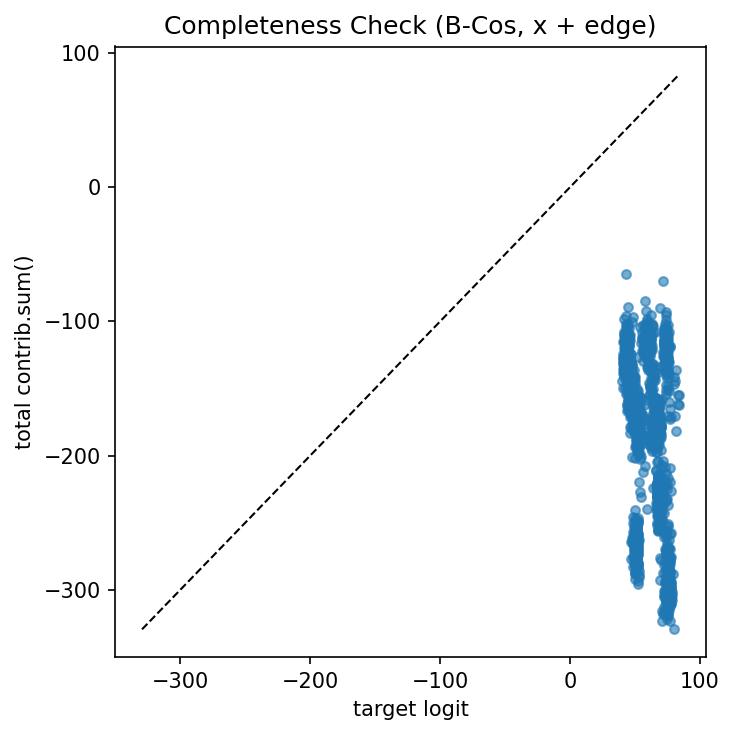

In [22]:
model = final_model.eval()
test_items = test_ds

target_logits = []
contrib_sums = []
x_sums = []
edge_sums = []

for d in test_items:
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        logits = model(d.x, d.edge_index, d.edge_attr, d.batch)
        pred_class = int(logits.argmax(dim=-1).item())
        target_logits.append(logits[0, pred_class].detach().cpu())

    contrib = explain_edge_attr(
        model, d.x, d.edge_index, d.edge_attr, d.batch, target=pred_class
    )
    node_contributions = contrib["x"]
    x_sum = node_contributions.sum().detach().cpu()
    edge_contributions = contrib.get("edge_attr", None)
    if edge_contributions is not None:
        edge_sum = edge_contributions.sum().detach().cpu()
    else:
        edge_sum = torch.tensor(0.0)
    total_sum = x_sum + edge_sum
    x_sums.append(x_sum)
    edge_sums.append(edge_sum)
    contrib_sums.append(total_sum)

if target_logits:
    target_logits = torch.stack(target_logits)
    contrib_sums = torch.stack(contrib_sums)
    x_sums = torch.stack(x_sums)
    edge_sums = torch.stack(edge_sums)
    diffs = (target_logits - contrib_sums)
    abs_diffs = diffs.abs()

    print(f"target_logit total: {target_logits.sum().item():.6f}")
    print(f"x_contrib.sum() total: {x_sums.sum().item():.6f}")
    print(f"edge_contrib.sum() total: {edge_sums.sum().item():.6f}")
    print(f"total_contrib.sum() total: {contrib_sums.sum().item():.6f}")
    print(f"mean |diff|: {abs_diffs.mean().item():.6f}")
    print(f"max |diff|: {abs_diffs.max().item():.6f}")
    print(f"median |diff|: {abs_diffs.median().item():.6f}")

    # Small summary table
    try:
        import pandas as pd
        summary_df = pd.DataFrame({
            "metric": ["mean_abs_diff", "median_abs_diff", "max_abs_diff", "mean_signed_diff"],
            "value": [
                float(abs_diffs.mean().item()),
                float(abs_diffs.median().item()),
                float(abs_diffs.max().item()),
                float(diffs.mean().item()),
            ],
        })
        display(summary_df)
    except Exception as e:
        print(f"(Summary table skipped: {e})")

    # Scatter plot: target logit vs total contrib sum
    try:
        import matplotlib.pyplot as plt
        x = target_logits.numpy()
        y = contrib_sums.numpy()
        min_v = float(min(x.min(), y.min()))
        max_v = float(max(x.max(), y.max()))
        plt.figure(figsize=(5, 5), dpi=150)
        plt.scatter(x, y, s=18, alpha=0.6)
        plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
        plt.xlabel("target logit")
        plt.ylabel("total contrib.sum()")
        plt.title("Completeness Check (B-Cos, x + edge)")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"(Scatter plot skipped: {e})")
else:
    print("No test items found in test_ds.")

Checking Multiclass Completeness: 100%|██████████| 500/500 [00:01<00:00, 454.85it/s]




B-cos Multiclass Completeness Gap (MAE): 2.39e+02


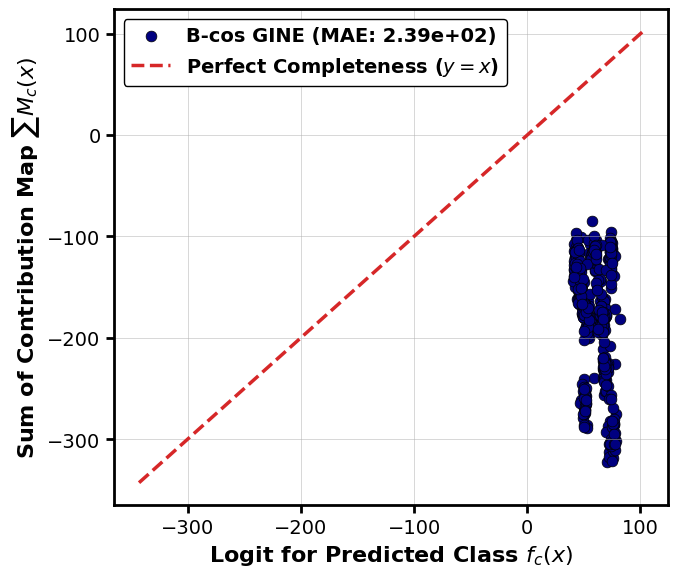

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

# --- 1. Publication Quality Global Settings ---
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.labelweight': 'bold',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.figsize': (7, 6), 
    'axes.linewidth': 2.0,    
    'font.family': 'sans-serif' 
})

def run_multiclass_completeness_check(dataset, model, device='cpu', max_samples=500):
    model.eval()
    
    bcos_logits = []
    bcos_contrib_sums = []

    # Iterate over the test set (limit to max_samples for speed if desired)
    for i, data in enumerate(tqdm(dataset[:max_samples], desc="Checking Multiclass Completeness")):
        data = data.to(device)
        data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
        
        # 1. Get Model Prediction (Logits for all 9 classes)
        with torch.no_grad():
            logits = model(data.x, data.edge_index, data.edge_attr, data.batch)
            
            # Find the winning class (the prediction)
            pred_class = int(logits.argmax(dim=-1).item())
            
            # Get the exact mathematical logit score for that winning class
            target_logit = logits[0, pred_class].item()
            
        # 2. Get B-cos Contributions specifically for the winning class
        contrib = explain_edge_attr(
            model,
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            target=pred_class # Target the explainer at the specific class logit!
        )
        
        # 3. Sum the RAW (signed) contributions for nodes and edges
        # Note: We DO NOT use .abs() here. Completeness requires the signed math.
        total_node_contrib = contrib['x'].sum().item()
        total_edge_contrib = contrib['edge_attr'].sum().item()
        
        total_contrib_sum = total_node_contrib + total_edge_contrib
        
        # Store for plotting
        bcos_logits.append(target_logit)
        bcos_contrib_sums.append(total_contrib_sum)

    # --- Metrics ---
    bcos_mae = np.mean(np.abs(np.array(bcos_logits) - np.array(bcos_contrib_sums)))
    print(f"\nB-cos Multiclass Completeness Gap (MAE): {bcos_mae:.2e}")

    # --- Plotting ---
    fig, ax = plt.subplots()

    # Plot B-cos data
    ax.scatter(bcos_logits, bcos_contrib_sums, alpha=1.0, s=60, 
               label=f'B-cos GINE (MAE: {bcos_mae:.2e})', color='navy', edgecolors='black', linewidths=0.5)

    # Plot the ideal "Perfect Completeness" line (y = x)
    min_val = min(min(bcos_logits), min(bcos_contrib_sums))
    max_val = max(max(bcos_logits), max(bcos_contrib_sums))
    
    # Adding a slight buffer to the axis limits so dots don't sit exactly on the edge
    buffer = (max_val - min_val) * 0.05
    ax.plot([min_val - buffer, max_val + buffer], 
            [min_val - buffer, max_val + buffer], 
            color='#d62728', linestyle='--', linewidth=2.5, label='Perfect Completeness ($y=x$)')

    ax.set_xlabel('Logit for Predicted Class $f_c(x)$')
    ax.set_ylabel('Sum of Contribution Map $\\sum M_c(x)$')

    # Configure Legend
    legend = ax.legend(loc='best', frameon=True, edgecolor='black', framealpha=1.0)
    for text in legend.get_texts():
        text.set_weight("bold")

    # Grid and Ticks
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
    ax.tick_params(axis='both', which='major', width=2.0, length=6)

    plt.tight_layout()

    # Save for NeurIPS
    plt.savefig('completeness_check_dihalo_multiclass.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Run the check on the test set
# (Using final_model from your notebook)
run_multiclass_completeness_check(test_ds, final_model, device=DEVICE, max_samples=500)

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque
from torch_geometric.utils import to_networkx

# -------------------------
# Utilities (Logic Unchanged)
# -------------------------
def _y_int(d):
    y = d.y
    return int(y.view(-1)[0].item()) if torch.is_tensor(y) else int(y)

def _bool_mask(m, n):
    if m is None:
        return np.zeros(n, dtype=bool)
    if torch.is_tensor(m):
        m = m.detach().cpu().numpy()
    m = np.asarray(m).astype(bool).reshape(-1)
    if len(m) != n:
        m = m[:n]
    return m

def _adj_from_edge_index(edge_index, n):
    adj = [[] for _ in range(n)]
    ei = edge_index.detach().cpu().numpy()
    for u, v in ei.T:
        u = int(u); v = int(v)
        adj[u].append(v)
    return adj

def _bfs_shortest_path(adj, src, dst):
    if src == dst:
        return [src]
    q = deque([src])
    prev = {src: None}
    while q:
        u = q.popleft()
        for v in adj[u]:
            if v in prev:
                continue
            prev[v] = u
            if v == dst:
                q.clear()
                break
            q.append(v)
    if dst not in prev:
        return None
    path = []
    cur = dst
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    path.reverse()
    return path

def _safe_atom_index(symbol):
    try:
        # Assumes get_one_hot_atom is available in your scope
        v = np.asarray(get_one_hot_atom(symbol), dtype=float)
        return int(np.argmax(v))
    except Exception:
        return None

IDX = {
    "C": _safe_atom_index("C"),
    "F": _safe_atom_index("F"),
    "Cl": _safe_atom_index("Cl"),
    "Br": _safe_atom_index("Br"),
}

# Full atom vocab used by get_one_hot_atom (for readable node labels)
ATOM_VOCAB = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P']
IDX_TO_SYM = {}
for _sym in ATOM_VOCAB:
    _idx = _safe_atom_index(_sym)
    if _idx is not None:
        IDX_TO_SYM[_idx] = _sym

def _node_symbol_from_x(d, i):
    x = d.x
    if torch.is_tensor(x):
        j = int(x[i].detach().cpu().argmax().item())
    else:
        j = int(np.asarray(x[i]).argmax())
    return IDX_TO_SYM.get(j, "?")

def _node_is_symbol(d, i, sym):
    idx = IDX.get(sym, None)
    if idx is None:
        return False
    x = d.x
    if torch.is_tensor(x):
        return bool(x[i, idx].detach().cpu().item() > 0.5)
    return bool(x[i, idx] > 0.5)

def _node_symbol_guess(d, i):
    return _node_symbol_from_x(d, i)

def _pick_5_per_class(test_ds, num_classes, seed=0):
    rng = np.random.default_rng(seed)
    idx_by_c = [[] for _ in range(num_classes)]
    for i, d in enumerate(test_ds):
        idx_by_c[_y_int(d)].append(i)
    picks = {}
    for c in range(num_classes):
        arr = np.array(idx_by_c[c], dtype=int)
        rng.shuffle(arr)
        picks[c] = arr[: min(5, len(arr))].tolist()
    return picks


# -------------------------
# Motif Logic
# -------------------------
def _halogen_nodes(d):
    n = d.num_nodes
    h = []
    for i in range(n):
        if _node_is_symbol(d, i, "Cl") or _node_is_symbol(d, i, "Br") or _node_is_symbol(d, i, "F"):
            h.append(i)
    return h

def _attachment_carbon(adj, d, halogen_node):
    neigh = adj[halogen_node]
    if not neigh:
        return None
    for v in neigh:
        if _node_is_symbol(d, v, "C"):
            return v
    return neigh[0]

def _position_path_mask_from_halogen_pair(d, h1, h2):
    n = d.num_nodes
    adj = _adj_from_edge_index(d.edge_index, n)
    a1 = _attachment_carbon(adj, d, h1)
    a2 = _attachment_carbon(adj, d, h2)
    if a1 is None or a2 is None:
        return None, None, None

    path = _bfs_shortest_path(adj, a1, a2)
    if path is None:
        return None, None, None

    mask = np.zeros(n, dtype=bool)
    for p in path:
        mask[int(p)] = True
    mask[int(h1)] = True
    mask[int(h2)] = True
    return mask, path, (a1, a2)

def _gt_position_mask(d):
    n = d.num_nodes
    gt = _bool_mask(getattr(d, "explanation_mask", None), n)
    if not gt.any():
        return None, None

    hal = [i for i in range(n) if gt[i] and (_node_is_symbol(d, i, "Cl") or _node_is_symbol(d, i, "Br") or _node_is_symbol(d, i, "F"))]
    if len(hal) < 2:
        return gt, None

    h1, h2 = hal[0], hal[1]
    pmask, path, _ = _position_path_mask_from_halogen_pair(d, h1, h2)
    return (pmask if pmask is not None else gt), path

def _pred_position_mask_from_scores(d, scores):
    hal = _halogen_nodes(d)
    if len(hal) < 2:
        return None, None

    hal = sorted(hal, key=lambda i: float(scores[i]), reverse=True)
    h1, h2 = hal[0], hal[1]

    pmask, path, anchors = _position_path_mask_from_halogen_pair(d, h1, h2)
    return pmask, (h1, h2, anchors, path)

def _explain_scores(final_model, d, target_class):
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)
    final_model.eval()
    with torch.no_grad():
        logits = final_model(d.x, d.edge_index, d.edge_attr, d.batch)
        pred = int(logits.argmax(dim=-1).item())
    contrib = explain_edge_attr(final_model, d.x, d.edge_index, d.edge_attr, d.batch, target=int(target_class))
    scores = node_scores_from_contrib(contrib["x"])
    return pred, scores


# -------------------------
# Improved Layout & Drawing
# -------------------------
def _layout(d):
    G = to_networkx(d, to_undirected=True)
    # Kamada-Kawai gives the best "chemical structure" look
    try:
        pos = nx.kamada_kawai_layout(G, scale=2.0)
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=0.5)
    return G, pos

def _draw(ax, d, G, pos, title="", highlight_path=None, highlight_hal=None,
          path_color="#4daf4a", hal_color="#e41a1c"):
    """
    Cleaner drawing function for print.
    - path_color: Color for the structural path (default: Green)
    - hal_color: Color for the specific atoms/halogens (default: Red)
    """
    n = d.num_nodes

    # 1. Setup Base Styles (Unimportant nodes)
    # Using 'whitesmoke' or very light grey for non-active nodes saves ink and reduces noise
    node_colors = ["#f0f0f0"] * n
    node_sizes = [200] * n  # Smaller default size
    node_borders = ["#cccccc"] * n
    border_widths = [1.0] * n

    # Edges
    edge_colors = ["#e0e0e0"] * G.number_of_edges()
    edge_widths = [1.0] * G.number_of_edges()

    # 2. Logic to highlight specific nodes/edges
    # We create a specific list for highlighted edges to draw them ON TOP
    highlighted_edges = []

    # Helper to check if node i is highlighted
    is_path = np.zeros(n, dtype=bool)
    if highlight_path is not None:
        is_path = np.asarray(highlight_path, dtype=bool)

    is_hal = np.zeros(n, dtype=bool)
    if highlight_hal is not None:
        is_hal = np.asarray(highlight_hal, dtype=bool)

    # Update Node Styles
    for i in range(n):
        if is_hal[i]:
            node_colors[i] = hal_color
            node_sizes[i] = 450
            node_borders[i] = "#333333"  # Dark grey border
            border_widths[i] = 2.0
        elif is_path[i]:
            node_colors[i] = path_color
            node_sizes[i] = 350
            node_borders[i] = "#333333"
            border_widths[i] = 1.5

    # Update Edge Styles (Color edges if both endpoints are in the mask)
    edges_list = list(G.edges())
    edge_color_list = []
    edge_width_list = []

    for u, v in edges_list:
        # If both nodes are part of the path/halogens, highlight the edge
        if (is_path[u] or is_hal[u]) and (is_path[v] or is_hal[v]):
            edge_color_list.append("#555555")  # Dark grey for the path
            edge_width_list.append(2.0)
        else:
            edge_color_list.append("#e0e0e0")  # Faint grey for context
            edge_width_list.append(0.8)

    # 3. Draw Sequence (Z-Order is crucial for neatness)

    # A. Draw Edges
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=edges_list,
        edge_color=edge_color_list,
        width=edge_width_list,
        alpha=0.9
    )

    # B. Draw Nodes
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=range(n),
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors=node_borders,
        linewidths=border_widths,
    )

    # C. Draw Labels (Only highlighted nodes to reduce clutter)
    labels = {}
    for i in range(n):
        if is_hal[i] or is_path[i]:
            labels[i] = _node_symbol_guess(d, i)

    nx.draw_networkx_labels(
        G, pos, labels=labels, font_size=10, ax=ax, font_weight='bold'
    )

    # Remove axis box
    ax.set_axis_off()

    # Clean Title
    ax.set_title(title, fontsize=10, y=0.95)


# -------------------------
# Main Execution
# -------------------------
_required = [
    "test_ds",
    "final_model",
    "DEVICE",
    "motifs",
    "explain_edge_attr",
    "node_scores_from_contrib",
]
_missing = [k for k in _required if k not in globals()]

if _missing:
    print(
        "Skipping visualization cell because required variables are missing: "
        + ", ".join(_missing)
        + ".\nRun the earlier setup/training cells first, then re-run this cell."
    )
else:
    NUM_CLASSES = int(max(_y_int(d) for d in test_ds) + 1)
    SEED_VIS = 0

    # Optional: Load class names if available
    CLASS_NAMES = None
    try:
        CLASS_NAMES = {k: v[1] for k, v in motifs.items()}
    except Exception:
        pass

    picks = _pick_5_per_class(test_ds, NUM_CLASSES, seed=SEED_VIS)

    for c in range(NUM_CLASSES):
        idxs = picks.get(c, [])
        if len(idxs) == 0:
            continue

        # Increase Figure Size and DPI for print quality
        fig, axes = plt.subplots(3, 5, figsize=(20, 10), dpi=300)

        cls_name = CLASS_NAMES.get(c, str(c)) if CLASS_NAMES else str(c)
        fig.suptitle(f"Class {c}: {cls_name}", fontsize=16, fontweight='bold', y=0.98)

        datas = []
        layouts = []
        for idx in idxs:
            d = test_ds[idx].cpu()
            G, pos = _layout(d)
            datas.append(d)
            layouts.append((G, pos))

        # Handle empty columns
        for col in range(5):
            if col >= len(datas):
                for r in range(3):
                    axes[r, col].remove()  # Completely remove axis
                continue

            idx = idxs[col]
            d = datas[col]
            G, pos = layouts[col]

            # -----------------------------
            # Row 1: Original Graph (Context)
            # -----------------------------
            _draw(axes[0, col], d, G, pos, title=f"Example {idx}\n(True y={_y_int(d)})")

            # -----------------------------
            # Row 2: Ground Truth (Blue/Green Theme)
            # -----------------------------
            gt_mask, gt_path = _gt_position_mask(d)
            gt_hal = np.zeros(d.num_nodes, dtype=bool)
            for i in range(d.num_nodes):
                if gt_mask is not None and gt_mask[i] and (_node_symbol_guess(d, i) in ["Cl", "Br", "F"]):
                    gt_hal[i] = True

            _draw(
                axes[1, col], d, G, pos,
                title="Ground Truth Motif",
                highlight_path=(gt_mask if gt_mask is not None else None),
                highlight_hal=gt_hal,
                path_color="#a6cee3",  # Light Blue
                hal_color="#1f78b4",   # Dark Blue
            )

            # -----------------------------
            # Row 3: Model Prediction (Red Theme)
            # -----------------------------
            pred_class, scores = _explain_scores(final_model, d, target_class=c)
            pmask, meta = _pred_position_mask_from_scores(d, scores)

            if pmask is None:
                # Fallback for display
                n = d.num_nodes
                k = int(gt_mask.sum()) if gt_mask is not None else min(5, n)
                top_idx = np.argsort(scores)[-k:]
                pmask = np.zeros(n, dtype=bool); pmask[top_idx] = True
                phal = np.zeros(n, dtype=bool)
            else:
                h1, h2, anchors, path = meta
                phal = np.zeros(d.num_nodes, dtype=bool)
                phal[h1] = True
                phal[h2] = True

            _draw(
                axes[2, col], d, G, pos,
                title=f"Prediction (Pred={pred_class})",
                highlight_path=pmask,
                highlight_hal=phal,
                path_color="#fb9a99",  # Light Red
                hal_color="#e31a1c",   # Dark Red
            )

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


Skipping visualization cell because required variables are missing: motifs.
Run the earlier setup/training cells first, then re-run this cell.


Generating RDKit visualizations...


[14:26:45] Explicit valence for atom # 6 N, 4, is greater than permitted
[14:26:45] Explicit valence for atom # 6 N, 4, is greater than permitted


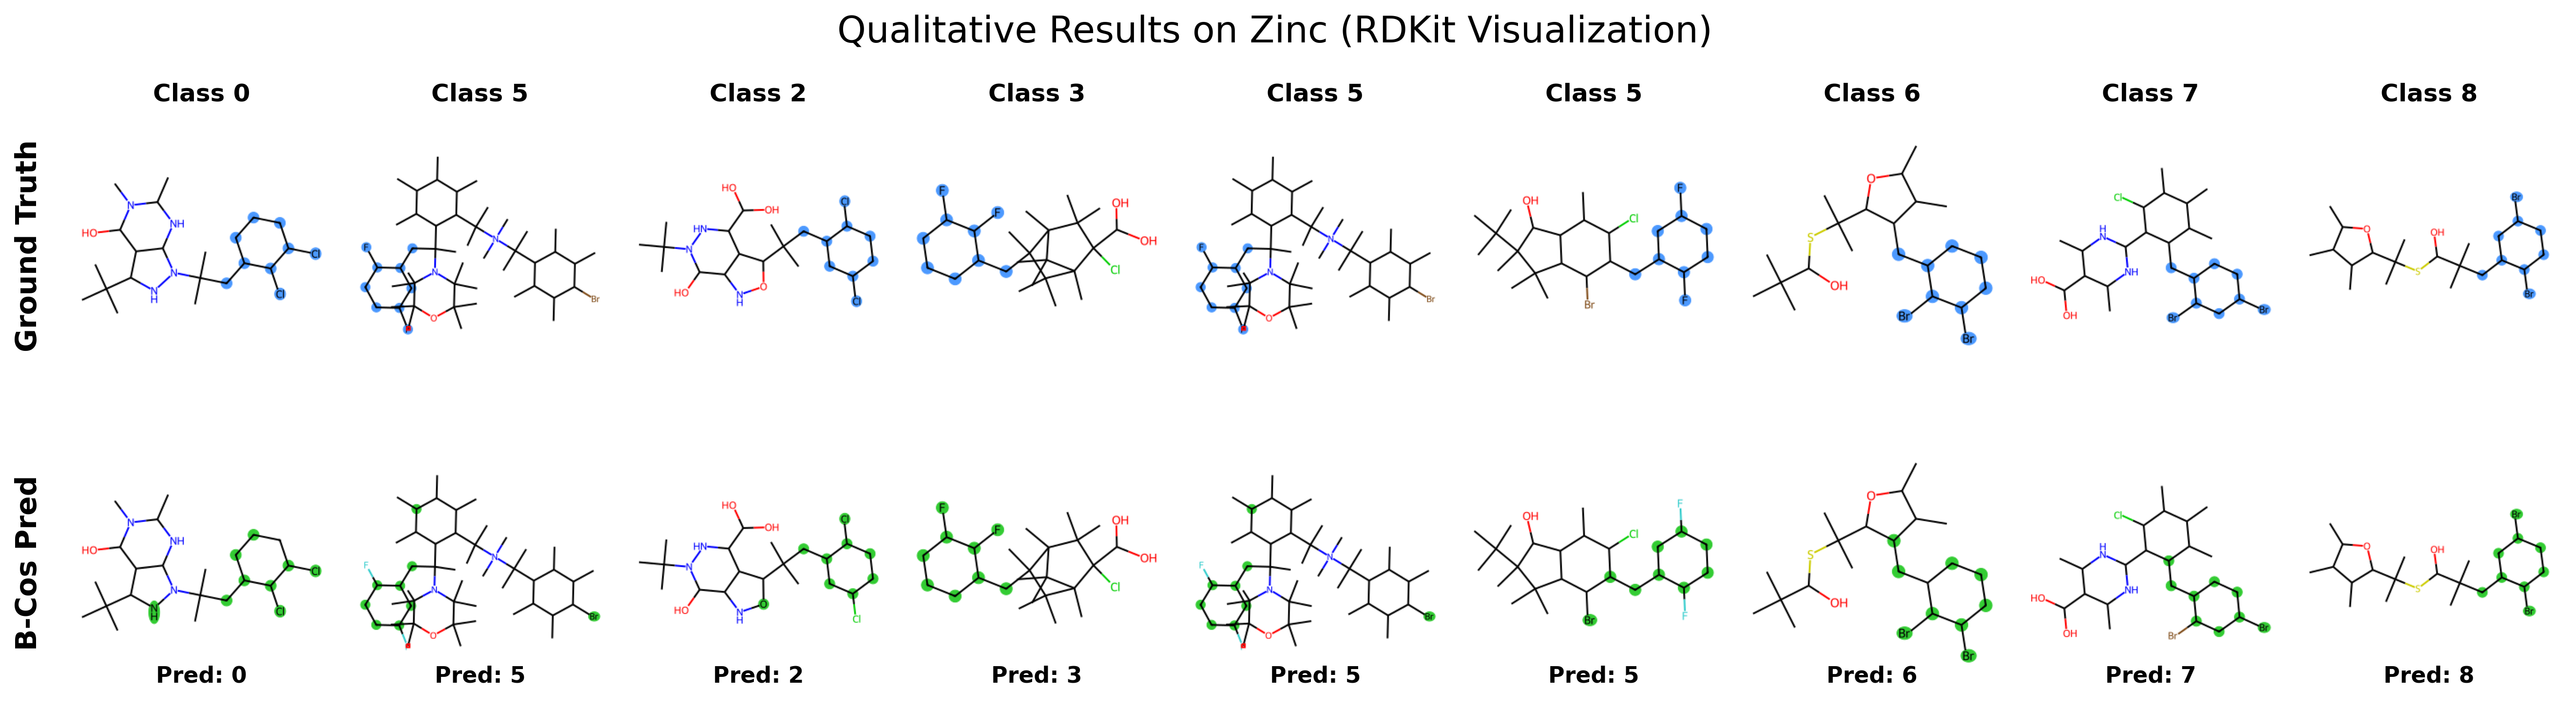

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem

# -------------------------------------------------------------------------
# 1. RDKit Conversion Utilities
# -------------------------------------------------------------------------
# ZINC atom map (Must match your dataset's feature encoding)
ATOM_MAP = {0: 6, 1: 7, 2: 8, 3: 16, 4: 9, 5: 17, 6: 35, 7: 53, 8: 15} # Atomic nums

def pyg_to_rdkit(data):
    """
    Converts a PyG graph to an RDKit molecule.
    Crucial step: We must infer bond types (Single, Double, Aromatic) 
    since standard GNN datasets often only store connectivity.
    """
    mol = Chem.RWMol()
    node_to_idx = {}
    
    # 1. Add Atoms
    for i in range(data.num_nodes):
        # Decode atom type
        if data.x.dim() > 1:
            atom_idx = data.x[i].argmax().item()
        else:
            atom_idx = int(data.x[i].item())
        
        atomic_num = ATOM_MAP.get(atom_idx, 6) # Default to Carbon if unknown
        atom = Chem.Atom(atomic_num)
        idx = mol.AddAtom(atom)
        node_to_idx[i] = idx

    # 2. Add Bonds (Initially all Single)
    edge_index = data.edge_index.cpu().numpy()
    # Use set to avoid adding double bonds for undirected edges (u,v) and (v,u)
    added_bonds = set()
    
    for k in range(edge_index.shape[1]):
        u, v = edge_index[0, k], edge_index[1, k]
        if u < v: # store only one direction
            mol.AddBond(int(node_to_idx[u]), int(node_to_idx[v]), Chem.BondType.SINGLE)
    
    # 3. Sanitize & Assign Bond Orders
    # This function attempts to figure out aromaticity and bond orders based on valency
    try:
        Chem.SanitizeMol(mol)
    except:
        pass # If sanitization fails, we still return the rough connectivity
        
    return mol

# -------------------------------------------------------------------------
# 2. Selection Logic (Same as before)
# -------------------------------------------------------------------------
def get_best_example_per_class(dataset, num_classes):
    candidates = {c: [] for c in range(num_classes)}
    indices = np.random.permutation(len(dataset))[:1000]
    
    for idx in indices:
        data = dataset[int(idx)]
        y = int(data.y.item()) if torch.is_tensor(data.y) else int(data.y)
        has_mask = hasattr(data, "explanation_mask") and data.explanation_mask is not None
        # RDKit draws look best with medium sized molecules
        if has_mask and 10 <= data.num_nodes <= 30:
             candidates[y].append(int(idx))
    
    selected = []
    for c in range(num_classes):
        if candidates[c]: selected.append(candidates[c][0])
        else: selected.append(0) # fallback
    return selected

# -------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model.to(DEVICE)
final_model.eval()

selected_indices = get_best_example_per_class(test_ds, 9)
cols = len(selected_indices)

# Setup subplots
fig, axes = plt.subplots(2, cols, figsize=(22, 5.5), dpi=300)
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Row Labels
rows = ["Ground Truth", "B-Cos Pred"]
for i, r in enumerate(rows):
    axes[i, 0].text(-0.1, 0.5, r, transform=axes[i, 0].transAxes, 
                    fontsize=14, fontweight='bold', rotation=90, va='center', ha='right')

print("Generating RDKit visualizations...")

for col, idx in enumerate(selected_indices):
    data = test_ds[idx].clone().to(DEVICE)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)
    true_cls = int(data.y.item())
    
    # Convert to RDKit
    mol = pyg_to_rdkit(data)
    
    # ------------------------------------------------
    # 1. Row 1: Ground Truth (Blue Highlights)
    # ------------------------------------------------
    if hasattr(data, "explanation_mask") and data.explanation_mask is not None:
        gt_mask = data.explanation_mask.cpu().numpy().astype(bool)
        gt_atoms = [int(i) for i in np.where(gt_mask)[0]]
    else:
        gt_atoms = []

    img_gt = Draw.MolToImage(mol, size=(300, 300), 
                             highlightAtoms=gt_atoms,
                             highlightColor=(0.3, 0.6, 1.0)) # Light Blue
    
    axes[0, col].imshow(img_gt)
    axes[0, col].set_title(f"Class {true_cls}", fontsize=12, fontweight='bold')
    axes[0, col].axis('off')

    # ------------------------------------------------
    # 2. Row 2: Prediction (Green/Red Highlights)
    # ------------------------------------------------
    # Forward Pass
    with torch.no_grad():
        logits = final_model(data.x, data.edge_index, data.edge_attr, data.batch)
        pred_cls = logits.argmax(dim=-1).item()
    
    # Explain
    contrib = explain_edge_attr(final_model, data.x, data.edge_index, data.edge_attr, data.batch, target=pred_cls)
    scores = contrib['x'].abs().sum(dim=-1).detach().cpu().numpy()
    
    # Top-K
    k = len(gt_atoms) if len(gt_atoms) > 0 else 5
    top_k_idx = np.argsort(scores)[-k:]
    pred_atoms = [int(i) for i in top_k_idx]
    
    # Color
    color = (0.2, 0.8, 0.2) if pred_cls == true_cls else (0.9, 0.2, 0.2) # Green or Red
    
    img_pred = Draw.MolToImage(mol, size=(300, 300), 
                               highlightAtoms=pred_atoms,
                               highlightColor=color)
    
    axes[1, col].imshow(img_pred)
    axes[1, col].text(0.5, 0.05, f"Pred: {pred_cls}", transform=axes[1, col].transAxes,
                      ha='center', fontsize=11, fontweight='bold', 
                      bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    axes[1, col].axis('off')

plt.suptitle("Qualitative Results on Zinc (RDKit Visualization)", fontsize=18, y=0.98)
plt.savefig("zinc_results_rdkit.pdf", bbox_inches='tight')
plt.show()

Generating HD RDKit visualizations...


[13:07:52] Explicit valence for atom # 2 N, 4, is greater than permitted


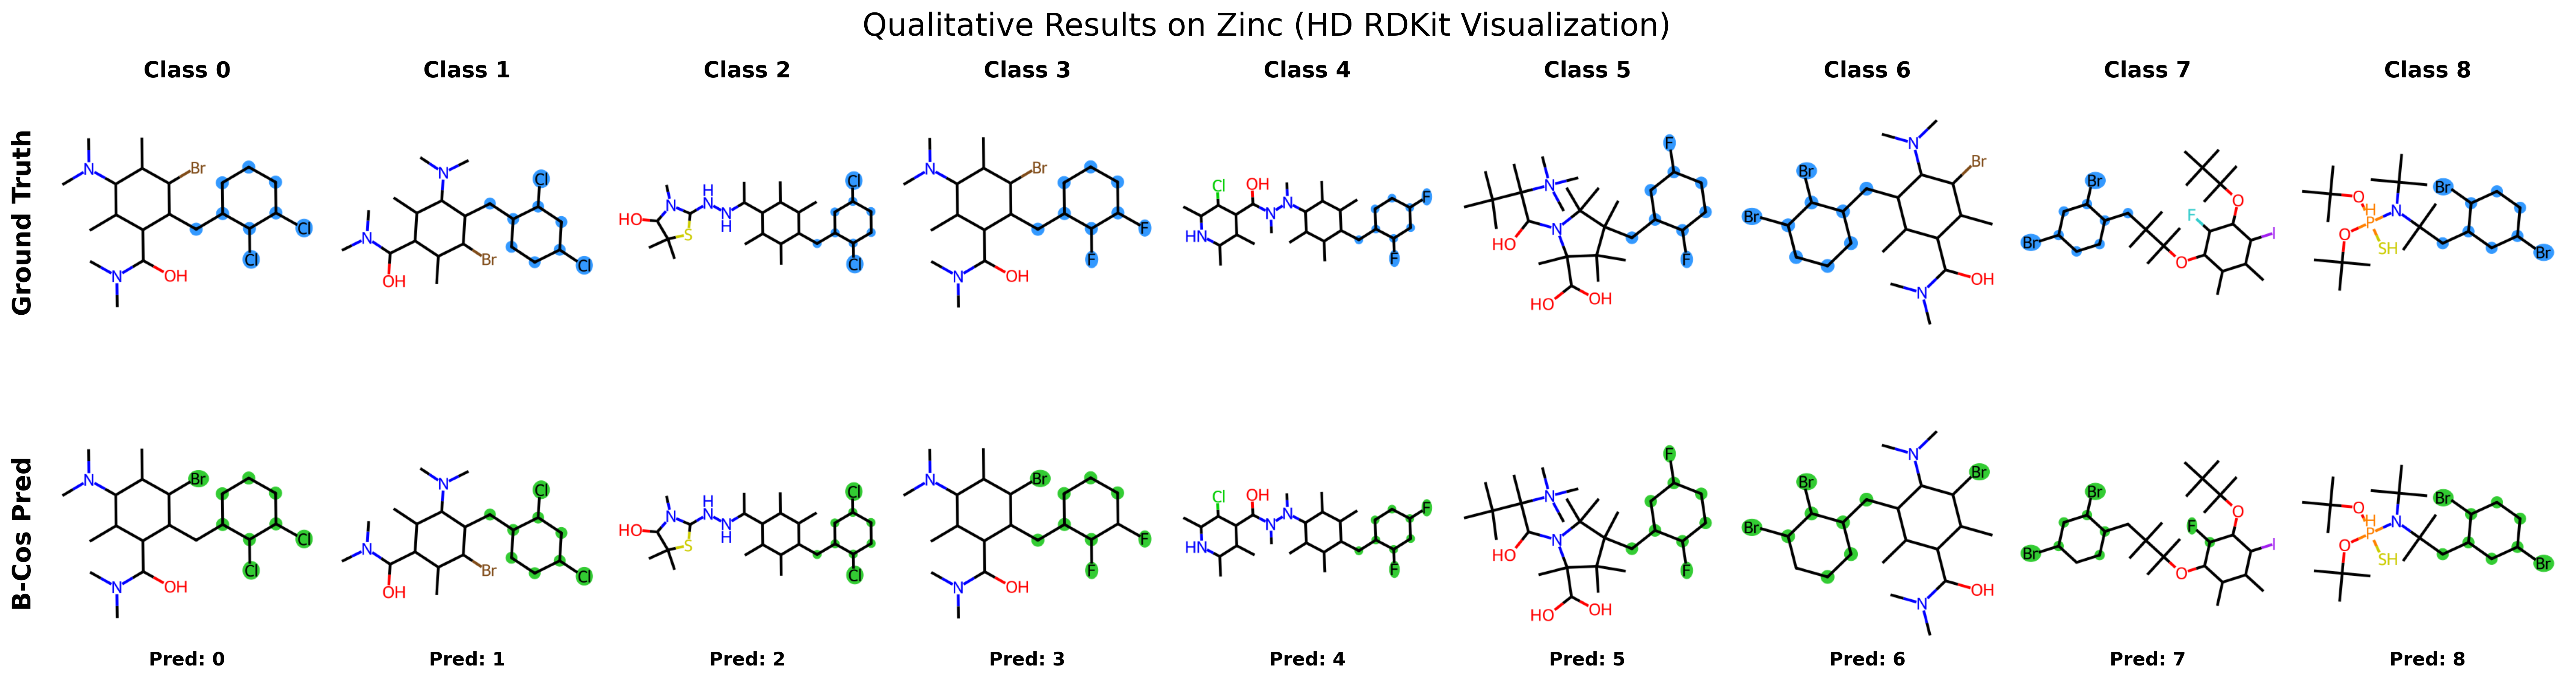

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import io
from PIL import Image
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D

# -------------------------------------------------------------------------
# 1. High-Definition RDKit Drawing Helper
# -------------------------------------------------------------------------
def draw_rdkit_hd(mol, highlight_atoms=None, highlight_color=(0.3, 0.6, 1.0)):
    """
    Draws a molecule with enlarged atoms and bonds for publication readability.
    """
    # 1. Setup Canvas (High Res)
    width, height = 400, 400
    d2d = rdMolDraw2D.MolDraw2DCairo(width, height)
    
    # 2. Customize Options (Make everything BIGGER)
    opts = d2d.drawOptions()
    opts.minFontSize = 24        # Minimum font size for atom labels
    opts.maxFontSize = 34        # Maximum font size
    opts.bondLineWidth = 4       # Thicker bonds
    opts.highlightBondWidthMultiplier = 1  # Keep highlights aligned with bonds
    opts.annotationFontScale = 1.0
    opts.padding = 0.05          # Less whitespace around the molecule
    
    # Ensure layout is computed
    if not mol.GetNumConformers():
        AllChem.Compute2DCoords(mol)

    # 3. Draw
    # Standardize highlighting format
    if highlight_atoms:
        # Create a dict for colors: {atom_idx: color_tuple}
        # Note: RDKit expects RGB tuples (0-1)
        hs = {idx: highlight_color for idx in highlight_atoms}
        d2d.DrawMolecule(mol, highlightAtoms=list(hs.keys()), highlightAtomColors=hs)
    else:
        d2d.DrawMolecule(mol)
        
    d2d.FinishDrawing()
    
    # 4. Convert to PIL Image for Matplotlib
    png_data = d2d.GetDrawingText()
    return Image.open(io.BytesIO(png_data))

# -------------------------------------------------------------------------
# 2. Conversion & Selection (Same as before)
# -------------------------------------------------------------------------
ATOM_MAP = {0: 6, 1: 7, 2: 8, 3: 16, 4: 9, 5: 17, 6: 35, 7: 53, 8: 15}

def pyg_to_rdkit(data):
    mol = Chem.RWMol()
    node_to_idx = {}
    
    # Add Atoms
    for i in range(data.num_nodes):
        if data.x.dim() > 1: atom_idx = data.x[i].argmax().item()
        else: atom_idx = int(data.x[i].item())
        mol.AddAtom(Chem.Atom(ATOM_MAP.get(atom_idx, 6)))
        node_to_idx[i] = i # RWMol indices are sequential

    # Add Bonds
    edge_index = data.edge_index.cpu().numpy()
    added = set()
    for k in range(edge_index.shape[1]):
        u, v = int(edge_index[0, k]), int(edge_index[1, k])
        if u < v:
            mol.AddBond(u, v, Chem.BondType.SINGLE)
            
    try: Chem.SanitizeMol(mol)
    except: pass
    return mol

def get_best_example_per_class(dataset, num_classes):
    candidates = {c: [] for c in range(num_classes)}
    indices = np.random.permutation(len(dataset))[:1000]
    for idx in indices:
        d = dataset[int(idx)]
        y = int(d.y.item()) if torch.is_tensor(d.y) else int(d.y)
        # Slightly relaxed constraints to ensure we find graphs
        if hasattr(d, "explanation_mask") and d.explanation_mask is not None:
             if 8 <= d.num_nodes <= 35: 
                 candidates[y].append(int(idx))
    
    selected = []
    for c in range(num_classes):
        selected.append(candidates[c][0] if candidates[c] else 0)
    return selected

# -------------------------------------------------------------------------
# 3. Main Plotting Loop (Updated)
# -------------------------------------------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model.to(DEVICE)
final_model.eval()

selected_indices = get_best_example_per_class(test_ds, 9)
cols = len(selected_indices)

# Increase figure size significantly to accommodate the HD images
fig, axes = plt.subplots(2, cols, figsize=(24, 7), dpi=300)
plt.subplots_adjust(wspace=0.02, hspace=0.05, left=0.05, right=0.98)

# Row Labels
rows = ["Ground Truth", "B-Cos Pred"]
for i, r in enumerate(rows):
    axes[i, 0].text(-0.05, 0.5, r, transform=axes[i, 0].transAxes, 
                    fontsize=16, fontweight='bold', rotation=90, va='center', ha='right')

print("Generating HD RDKit visualizations...")

for col, idx in enumerate(selected_indices):
    data = test_ds[idx].clone().to(DEVICE)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)
    true_cls = int(data.y.item())
    
    mol = pyg_to_rdkit(data)
    
    # --- Row 1: Ground Truth ---
    if hasattr(data, "explanation_mask") and data.explanation_mask is not None:
        gt_mask = data.explanation_mask.cpu().numpy().astype(bool)
        gt_atoms = [int(i) for i in np.where(gt_mask)[0]]
    else:
        gt_atoms = []

    # Use the new HD drawer
    img_gt = draw_rdkit_hd(mol, highlight_atoms=gt_atoms, highlight_color=(0.2, 0.6, 1.0)) # Bright Blue
    
    axes[0, col].imshow(img_gt)
    axes[0, col].set_title(f"Class {true_cls}", fontsize=14, fontweight='bold', pad=5)
    axes[0, col].axis('off')

    # --- Row 2: Prediction ---
    with torch.no_grad():
        logits = final_model(data.x, data.edge_index, data.edge_attr, data.batch)
        pred_cls = logits.argmax(dim=-1).item()
        
    contrib = explain_edge_attr(final_model, data.x, data.edge_index, data.edge_attr, data.batch, target=pred_cls)
    scores = contrib['x'].abs().sum(dim=-1).detach().cpu().numpy()
    
    k = len(gt_atoms) if len(gt_atoms) > 0 else 5
    top_k_idx = np.argsort(scores)[-k:]
    pred_atoms = [int(i) for i in top_k_idx]
    
    color = (0.2, 0.8, 0.2) if pred_cls == true_cls else (0.9, 0.1, 0.1) # Green or Red
    
    img_pred = draw_rdkit_hd(mol, highlight_atoms=pred_atoms, highlight_color=color)
    
    axes[1, col].imshow(img_pred)
    axes[1, col].text(0.5, 0.02, f"Pred: {pred_cls}", transform=axes[1, col].transAxes,
                      ha='center', fontsize=12, fontweight='bold', 
                      bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.2'))
    axes[1, col].axis('off')

plt.suptitle("Qualitative Results on Zinc (HD RDKit Visualization)", fontsize=20, y=0.96)
plt.savefig("zinc_results_rdkit_hd.pdf", bbox_inches='tight')
plt.show()

Searching dataset for representative molecules...


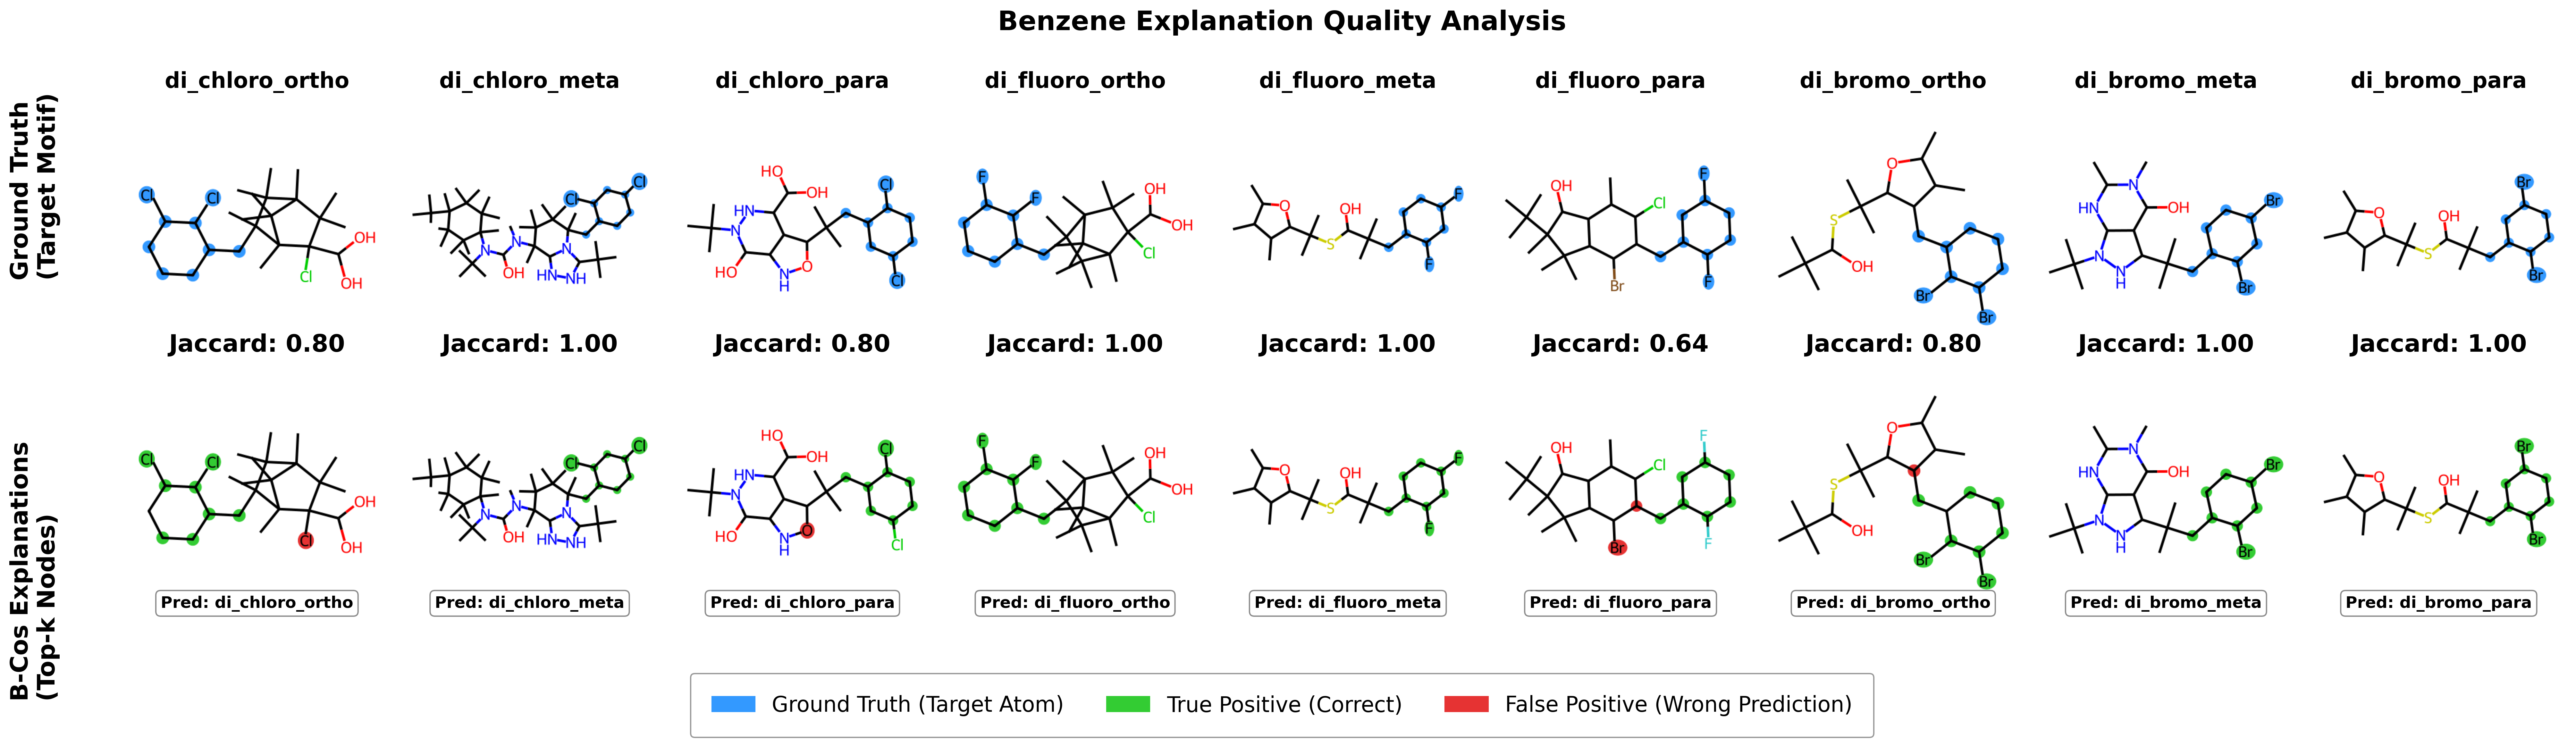

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import io
import functools
from PIL import Image
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
import matplotlib.patches as mpatches

# -------------------------------------------------------------------------
# 1. RDKit HD Drawer (Unchanged)
# -------------------------------------------------------------------------
def draw_rdkit_hd_mixed(mol, atom_colors=None):
    width, height = 400, 400
    d2d = rdMolDraw2D.MolDraw2DCairo(width, height)
    opts = d2d.drawOptions()
    opts.minFontSize = 24
    opts.maxFontSize = 34
    opts.bondLineWidth = 4
    opts.highlightBondWidthMultiplier = 1
    opts.padding = 0.05
    
    if not mol.GetNumConformers():
        AllChem.Compute2DCoords(mol)

    if atom_colors:
        d2d.DrawMolecule(mol, highlightAtoms=list(atom_colors.keys()), highlightAtomColors=atom_colors)
    else:
        d2d.DrawMolecule(mol)
        
    d2d.FinishDrawing()
    return Image.open(io.BytesIO(d2d.GetDrawingText()))

# -------------------------------------------------------------------------
# 2. Conversion Utilities (Unchanged)
# -------------------------------------------------------------------------
ATOM_MAP = {0: 6, 1: 7, 2: 8, 3: 16, 4: 9, 5: 17, 6: 35, 7: 53, 8: 15}

def pyg_to_rdkit(data):
    mol = Chem.RWMol()
    node_to_idx = {}
    for i in range(data.num_nodes):
        if data.x.dim() > 1: atom_idx = data.x[i].argmax().item()
        else: atom_idx = int(data.x[i].item())
        mol.AddAtom(Chem.Atom(ATOM_MAP.get(atom_idx, 6)))
        node_to_idx[i] = i 

    edge_index = data.edge_index.cpu().numpy()
    for k in range(edge_index.shape[1]):
        u, v = int(edge_index[0, k]), int(edge_index[1, k])
        if u < v:
            mol.AddBond(u, v, Chem.BondType.SINGLE)
            
    try: Chem.SanitizeMol(mol)
    except: pass
    return mol

# -------------------------------------------------------------------------
# 3. ROBUST Selection Logic
# -------------------------------------------------------------------------
def get_best_example_per_class(dataset, num_classes):
    candidates_strict = {c: [] for c in range(num_classes)}
    candidates_loose = {c: [] for c in range(num_classes)}
    
    # Shuffle for randomness
    indices = np.random.permutation(len(dataset))
    
    print("Searching dataset for representative molecules...")
    
    for idx in indices:
        if all(len(candidates_strict[c]) > 0 for c in range(num_classes)):
            break
            
        d = dataset[int(idx)]
        y = int(d.y.item()) if torch.is_tensor(d.y) else int(d.y)
        
        has_mask = hasattr(d, "explanation_mask") and d.explanation_mask is not None
        if not has_mask: 
            continue
            
        candidates_loose[y].append(int(idx))
        
        if 10 <= d.num_nodes <= 30:
            candidates_strict[y].append(int(idx))
    
    selected = []
    for c in range(num_classes):
        if candidates_strict[c]:
            selected.append(candidates_strict[c][0])
        elif candidates_loose[c]:
            print(f"Warning: Class {c} using sub-optimal size graph.")
            selected.append(candidates_loose[c][0])
        else:
            raise ValueError(f"Could not find ANY valid example for Class {c} with an explanation mask!")
            
    return selected

# -------------------------------------------------------------------------
# 4. Main Plotting Loop (UPDATED STYLE)
# -------------------------------------------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model.to(DEVICE)
final_model.eval()

selected_indices = get_best_example_per_class(test_ds, 9)
cols = len(selected_indices)

# Increase DPI and Figure Size
fig, axes = plt.subplots(2, cols, figsize=(3 * cols, 8), dpi=300)

labels =["di_chloro_ortho" , "di_chloro_meta", "di_chloro_para",
         "di_fluoro_ortho", "di_fluoro_meta", "di_fluoro_para",
         "di_bromo_ortho", "di_bromo_meta", "di_bromo_para"]

for col, idx in enumerate(selected_indices):
    data = test_ds[idx].clone().to(DEVICE)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)
    true_cls = int(data.y.item())
    
    mol = pyg_to_rdkit(data)
    
    # --- Row 1: Ground Truth (Blue) ---
    gt_indices = set()
    if hasattr(data, "explanation_mask") and data.explanation_mask is not None:
        mask = data.explanation_mask.cpu().numpy().astype(bool)
        gt_indices = set(int(i) for i in np.where(mask)[0])
    
    # Blue for Ground Truth
    gt_colors = {i: (0.2, 0.6, 1.0) for i in gt_indices}
    
    img_gt = draw_rdkit_hd_mixed(mol, atom_colors=gt_colors)
    axes[0, col].imshow(img_gt)
    
    # Font size 16 bold
    axes[0, col].set_title(labels[true_cls], fontsize=16, fontweight='bold', pad=10)
    axes[0, col].axis('off')

    # --- Row 2: Prediction ---
    with torch.no_grad():
        logits = final_model(data.x, data.edge_index, data.edge_attr, data.batch)
        pred_cls = logits.argmax(dim=-1).item()
        
    contrib = explain_edge_attr(final_model, data.x, data.edge_index, data.edge_attr, data.batch, target=pred_cls)
    scores = contrib['x'].abs().sum(dim=-1).detach().cpu().numpy()
    
    # Top-K
    k = len(gt_indices) if len(gt_indices) > 0 else 5
    top_k_idx = np.argsort(scores)[-k:]
    pred_indices = set(int(i) for i in top_k_idx)
    
    # Jaccard
    intersection = len(gt_indices.intersection(pred_indices))
    union = len(gt_indices.union(pred_indices))
    jaccard = intersection / union if union > 0 else 0.0
    
    # Colors
    pred_colors = {}
    for idx in pred_indices:
        if idx in gt_indices:
            pred_colors[idx] = (0.2, 0.8, 0.2) # Green (TP)
        else:
            pred_colors[idx] = (0.9, 0.2, 0.2) # Red (FP)
            
    img_pred = draw_rdkit_hd_mixed(mol, atom_colors=pred_colors)
    axes[1, col].imshow(img_pred)
    
    # Font size 18 bold for Jaccard
    axes[1, col].set_title(f"Jaccard: {jaccard:.2f}", fontsize=18, fontweight='bold', pad=10)
    
    # Pred label box
    axes[1, col].text(0.5, 0.05, f"Pred: {labels[pred_cls]}", transform=axes[1, col].transAxes,
                      ha='center', fontsize=12, fontweight='bold', 
                      bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.3'))
    axes[1, col].axis('off')

# --- Row Titles (Manual Placement) ---
fig.text(0.01, 0.75, "Ground Truth\n(Target Motif)", ha='left', va='center', 
         rotation=90, fontsize=18, fontweight='bold')
fig.text(0.01, 0.25, "B-Cos Explanations\n(Top-k Nodes)", ha='left', va='center', 
         rotation=90, fontsize=18, fontweight='bold')

# --- Legend ---
legend_elements = [
    mpatches.Patch(color=(0.2, 0.6, 1.0), label='Ground Truth (Target Atom)'),
    mpatches.Patch(color=(0.2, 0.8, 0.2), label='True Positive (Correct)'),
    mpatches.Patch(color=(0.9, 0.2, 0.2), label='False Positive (Wrong Prediction)'),
]

# Font size 16 for Legend
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.02), 
           frameon=True, fontsize=16, borderpad=1, edgecolor='gray')

plt.suptitle("Benzene Explanation Quality Analysis", fontsize=20, fontweight='bold', y=0.98)

# Adjust layout to fit row titles (left=0.05) and legend (bottom=0.14)
plt.tight_layout(rect=[0.05, 0.14, 1, 0.96])

plt.savefig("zinc_results_final.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

def run_multiseed_single_split(
    dataset,
    *,
    seeds=(0, 1, 2, 3, 4),
    test_size=0.2,
    val_size=0.1,  # Fraction of train_val set to use for validation
    hidden_dim=128,
    batch_size=64,
    max_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=10,
    min_lr=1e-6,
    early_stop_patience=25,
    min_delta=1e-4,
    num_workers=0,
    verbose=False,
    b=2.0,
    max_out=1,
    dropout=0.5,
):
    """
    Runs a multi-seed experiment with a single Train/Val/Test split per seed.
    """
    device = get_device()
    print(f"Device: {device}")
    print(f"Seeds: {list(seeds)}")
    print(f"Split sizes: Test={test_size}, Val (of remaining)={val_size}")
    
    # Get labels for stratified splitting
    y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)
    all_indices = np.arange(len(dataset))
    
    results = []
    
    t0 = time.time()
    
    for seed in seeds:
        seed_t0 = time.time()
        
        # 1. Split Total -> TrainVal + Test
        sss_test = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        trainval_idx, test_idx = next(sss_test.split(all_indices, y))
        
        # 2. Split TrainVal -> Train + Val
        y_trainval = y[trainval_idx]
        sss_val = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=seed)
        train_rel, val_rel = next(sss_val.split(np.zeros_like(y_trainval), y_trainval))
        
        train_idx = trainval_idx[train_rel]
        val_idx = trainval_idx[val_rel]
        
        # 3. Train
        out = train_one_run_bcos(
            dataset,
            train_idx=train_idx,
            val_idx=val_idx,
            test_idx=test_idx,
            seed=int(seed),
            hidden_dim=hidden_dim,
            batch_size=batch_size,
            max_epochs=max_epochs,
            lr=lr,
            weight_decay=weight_decay,
            scheduler_factor=scheduler_factor,
            scheduler_patience=scheduler_patience,
            min_lr=min_lr,
            early_stop_patience=early_stop_patience,
            min_delta=min_delta,
            num_workers=num_workers,
            verbose=verbose,
            device=device,
            b=b,
            max_out=max_out,
            dropout=dropout,
        )
        
        out['seed'] = int(seed)
        results.append(out)
        
        print(f"Seed {seed} | Test Acc: {out['test_acc']:.4f} | Val Acc: {out['best_val_acc']:.4f} | Epochs: {out['epochs_ran']} | Time: {time.time()-seed_t0:.1f}s")

    # --- Summary ---
    df = pd.DataFrame(results)
    mean_acc = df['test_acc'].mean()
    std_acc = df['test_acc'].std(ddof=1) if len(df) > 1 else 0.0
    elapsed = time.time() - t0
    
    print("\n==================================================")
    print(f"FINAL RESULTS (5 Seeds, No CV)")
    print("==================================================")
    print(f"Test Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"Total Time: {elapsed/60:.1f} min")
    
    return df

# --- Run the Experiment ---
# Ensure 'dataset' is loaded (from cell 3 of your notebook)
if 'dataset' in locals():
    df_results = run_multiseed_single_split(
        dataset,
        seeds=[0, 1, 2, 3, 4], # 5 seeds as requested
        test_size=0.2,
        val_size=0.1,          # 10% of training data used for validation
        hidden_dim=128,
        batch_size=64,
        max_epochs=200,
        lr=1e-3
    )
    
    # Display full table
    print("\nFull Results Table:")
    display(df_results[['seed', 'test_acc', 'best_val_acc', 'epochs_ran']])
else:
    print("Error: 'dataset' variable not found. Please run the data loading cells first.")

In [13]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

# Ensure these imports are available from your previous cells
# from bcosgnn.explain_edge_attr import explain as explain_edge_attr

def run_experiment_with_explanations(
    dataset,
    *,
    seeds=[0, 1, 2, 3, 4],
    test_size=0.2,
    val_size=0.1,  # Fraction of total for validation
    hidden_dim=128,
    batch_size=64,
    max_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=10,
    min_lr=1e-6,
    early_stop_patience=25,
    min_delta=1e-4,
    device=None,
    b=2.5,
    max_out=1,
    dropout=0.5,
    n_explain=500, # Max number of test graphs to explain per seed to save time
):
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Running Experiment on Device: {device}")
    print(f"Seeds: {seeds}")
    
    # Pre-calculate labels for splitting
    all_y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)
    all_indices = np.arange(len(dataset))
    
    # Store results for aggregation
    experiment_results = []
    
    global_start = time.time()

    for seed in seeds:
        seed_start = time.time()
        set_seed(seed) # Ensure reproducibility
        
        # --- 1. Data Splitting (Stratified) ---
        # Split: Total -> TrainVal + Test
        sss_test = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        trainval_idx, test_idx = next(sss_test.split(all_indices, all_y))
        
        # Split: TrainVal -> Train + Val
        y_trainval = all_y[trainval_idx]
        # Adjust val_size to be relative to trainval set
        rel_val_size = val_size / (1 - test_size)
        sss_val = StratifiedShuffleSplit(n_splits=1, test_size=rel_val_size, random_state=seed)
        train_rel, val_rel = next(sss_val.split(np.zeros_like(y_trainval), y_trainval))
        
        train_idx = trainval_idx[train_rel]
        val_idx = trainval_idx[val_rel]
        
        # Create Loaders
        train_loader = DataLoader(dataset.index_select(torch.tensor(train_idx)), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(dataset.index_select(torch.tensor(val_idx)), batch_size=batch_size, shuffle=False)
        # For testing/explanation, shuffle=False is important to match indices
        test_ds = dataset.index_select(torch.tensor(test_idx))
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

        # --- 2. Model Setup ---
        sample = dataset[0]
        model = BCosGINE(
            node_dim=int(sample.x.size(-1)),
            edge_dim=int(sample.edge_attr.size(-1)),
            hidden_dim=hidden_dim,
            num_layers=4,
            num_classes=_infer_num_classes(dataset),
            b=b,
            max_out=max_out,
            dropout=dropout,
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience, min_lr=min_lr
        )

        # --- 3. Training Loop ---
        best_state = None
        best_val_loss = float('inf')
        epochs_no_improve = 0
        
        for epoch in range(1, max_epochs + 1):
            # Train
            model.train()
            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                loss = F.cross_entropy(out, batch.y.view(-1))
                loss.backward()
                optimizer.step()
            
            # Validate
            model.eval()
            val_loss = 0
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                    val_loss += F.cross_entropy(out, batch.y.view(-1), reduction='sum').item()
                    val_correct += (out.argmax(dim=-1) == batch.y.view(-1)).sum().item()
                    val_total += batch.y.size(0)
            
            avg_val_loss = val_loss / val_total
            avg_val_acc = val_correct / val_total
            
            scheduler.step(avg_val_loss)
            
            if (best_val_loss - avg_val_loss) > min_delta:
                best_val_loss = avg_val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                
            if epochs_no_improve >= early_stop_patience:
                break
        
        # Load best model
        if best_state is not None:
            model.load_state_dict(best_state)
        model.to(device)
        model.eval()

        # --- 4. Test Evaluation (Accuracy) ---
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for batch in test_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                test_correct += (out.argmax(dim=-1) == batch.y.view(-1)).sum().item()
                test_total += batch.y.size(0)
        test_acc = test_correct / test_total

        # --- 5. Explanation Evaluation (Jaccard & AUROC) ---
        # We define a helper within scope to calculate node scores
        def get_node_scores(contrib):
            return contrib["x"].abs().sum(dim=-1).detach().cpu().numpy()

        aurocs = []
        jaccards = []
        
        # Limit explanation to n_explain samples to keep runtime reasonable
        explain_indices = np.random.choice(len(test_ds), size=min(len(test_ds), n_explain), replace=False)
        
        for i in explain_indices:
            data_item = test_ds[int(i)]
            
            # Skip if no ground truth explanation mask
            if not hasattr(data_item, "explanation_mask") or data_item.explanation_mask is None:
                continue
                
            data_item = data_item.to(device)
            # Create a batch of size 1
            data_item.batch = torch.zeros(data_item.x.size(0), dtype=torch.long, device=device)
            
            # Get prediction to explain
            with torch.no_grad():
                logits = model(data_item.x, data_item.edge_index, data_item.edge_attr, data_item.batch)
                pred_class = int(logits.argmax(dim=-1).item())
            
            # Run Explanation
            contrib = explain_edge_attr(
                model,
                data_item.x,
                data_item.edge_index,
                data_item.edge_attr,
                data_item.batch,
                target=pred_class
            )
            
            scores = get_node_scores(contrib)
            gt_mask = data_item.explanation_mask.detach().cpu().numpy().astype(int)
            
            # 1. AUROC (requires both classes 0 and 1 in gt)
            if gt_mask.min() != gt_mask.max():
                aurocs.append(roc_auc_score(gt_mask, scores))
            
            # 2. Jaccard @ k (k = number of ground truth nodes)
            k = int(gt_mask.sum())
            if k > 0:
                # Get indices of top-k scores
                top_k_indices = np.argsort(scores)[-k:]
                pred_mask = np.zeros_like(gt_mask)
                pred_mask[top_k_indices] = 1
                
                intersection = np.logical_and(gt_mask, pred_mask).sum()
                union = np.logical_or(gt_mask, pred_mask).sum()
                jaccards.append(intersection / union if union > 0 else 0.0)

        # Seed Stats
        mean_auroc = np.mean(aurocs) if aurocs else 0.0
        mean_jaccard = np.mean(jaccards) if jaccards else 0.0
        
        experiment_results.append({
            'seed': seed,
            'test_acc': test_acc,
            'auroc': mean_auroc,
            'jaccard': mean_jaccard,
            'n_explained': len(aurocs) # Should be roughly same for both
        })
        
        print(f"Seed {seed} | Test Acc: {test_acc:.4f} | AUROC: {mean_auroc:.4f} | Jaccard: {mean_jaccard:.4f} | Time: {time.time()-seed_start:.1f}s")

    # --- 6. Final Reporting ---
    df_res = pd.DataFrame(experiment_results)
    
    print("\n" + "="*60)
    print("FINAL RESULTS (5 Seeds, No CV)")
    print("="*60)
    
    stats = df_res[['test_acc', 'auroc', 'jaccard']].agg(['mean', 'std'])
    
    print(f"Test Accuracy : {stats.loc['mean', 'test_acc']:.4f} ± {stats.loc['std', 'test_acc']:.4f}")
    print(f"Explanation AUROC : {stats.loc['mean', 'auroc']:.4f} ± {stats.loc['std', 'auroc']:.4f}")
    print(f"Explanation Jaccard: {stats.loc['mean', 'jaccard']:.4f} ± {stats.loc['std', 'jaccard']:.4f}")
    print("-" * 60)
    print(f"Total Time: {(time.time() - global_start)/60:.1f} min")
    
    return df_res

# --- Execute ---
if 'dataset' in locals():
    results_df = run_experiment_with_explanations(
        dataset, 
        seeds=[0, 1, 2, 3, 4],
        max_epochs=200,
        n_explain=1800 # Set to full test size (1800) or lower (e.g. 200) for speed
    )
    display(results_df)
else:
    print("Dataset not found. Please run data loading cells first.")

Running Experiment on Device: cpu
Seeds: [0, 1, 2, 3, 4]
Seed 0 | Test Acc: 1.0000 | AUROC: 0.9994 | Jaccard: 0.9877 | Time: 150.0s
Seed 1 | Test Acc: 1.0000 | AUROC: 0.9814 | Jaccard: 0.8535 | Time: 162.3s
Seed 2 | Test Acc: 1.0000 | AUROC: 0.9989 | Jaccard: 0.9667 | Time: 156.6s
Seed 3 | Test Acc: 1.0000 | AUROC: 0.9906 | Jaccard: 0.8934 | Time: 169.6s
Seed 4 | Test Acc: 1.0000 | AUROC: 0.9856 | Jaccard: 0.8960 | Time: 162.9s

FINAL RESULTS (5 Seeds, No CV)
Test Accuracy : 1.0000 ± 0.0000
Explanation AUROC : 0.9912 ± 0.0080
Explanation Jaccard: 0.9194 ± 0.0558
------------------------------------------------------------
Total Time: 13.4 min


,seed,test_acc,auroc,jaccard,n_explained
0,0,1.0,0.999428,0.987657,1800
1,1,1.0,0.981355,0.853515,1800
2,2,1.0,0.998910,0.966652,1800
3,3,1.0,0.990567,0.893356,1800
4,4,1.0,0.985551,0.895996,1800


In [30]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

# Ensure these imports are available from your previous cells
# from bcosgnn.explain_edge_attr import explain as explain_edge_attr

def _sync_if_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def run_experiment_with_explanations(
    dataset,
    *,
    seeds=[0, 1, 2, 3, 4],
    test_size=0.2,
    val_size=0.1,  # Fraction of total for validation
    hidden_dim=128,
    batch_size=64,
    max_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=10,
    min_lr=1e-6,
    early_stop_patience=25,
    min_delta=1e-4,
    device=None,
    b=2.0,
    max_out=1,
    dropout=0.5,
    n_explain=500, # Max number of test graphs to explain per seed to save time
    explain_subset=None, # Optional list/array of indices to explain
    explain_shuffle=True,
    explain_seed=None,
    explain_k=None, # Optional top-k override for explanations (if None, uses |GT|
    compute_time=True,
    time_explain_only=True, # If True, only time explanation loop; else include preprocessing
    print_epoch_time=False,
    debug=False,
    # Optional cap on explain count per seed
    max_explain=None,
    # --- Timing Params ---
    warmup_explain=2,
    time_per_graph=False,
    # if True, record per-graph times and return mean, std, median, p90
    # else only total explain time
    # note: per-graph timing slightly increases overhead
    time_in_ms=True,
    # Use torch.cuda.synchronize for accurate timings on GPU
    sync_cuda=True,
    # --- Misc ---
    silent=False,
    # Run detailed logging?
    # Keep default False for speed
    # Set True to debug output
    # (Do not enable for final runs)
    # --- End ---
    ):
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if not silent:
        print(f"Running Experiment on Device: {device}")
        print(f"Seeds: {seeds}")
    
    # Pre-calculate labels for splitting
    all_y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)
    all_indices = np.arange(len(dataset))
    
    # Store results for aggregation
    experiment_results = []
    
    global_start = time.time()

    for seed in seeds:
        seed_start = time.time()
        set_seed(seed) # Ensure reproducibility
        
        # --- 1. Data Splitting (Stratified) ---
        # Split: Total -> TrainVal + Test
        sss_test = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        trainval_idx, test_idx = next(sss_test.split(all_indices, all_y))
        
        # Split: TrainVal -> Train + Val
        y_trainval = all_y[trainval_idx]
        # Adjust val_size to be relative to trainval set
        rel_val_size = val_size / (1 - test_size)
        sss_val = StratifiedShuffleSplit(n_splits=1, test_size=rel_val_size, random_state=seed)
        train_rel, val_rel = next(sss_val.split(np.zeros_like(y_trainval), y_trainval))
        
        train_idx = trainval_idx[train_rel]
        val_idx = trainval_idx[val_rel]
        
        # Create Loaders
        train_loader = DataLoader(dataset.index_select(torch.tensor(train_idx)), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(dataset.index_select(torch.tensor(val_idx)), batch_size=batch_size, shuffle=False)
        # For testing/explanation, shuffle=False is important to match indices
        test_ds = dataset.index_select(torch.tensor(test_idx))
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

        # --- 2. Model Setup ---
        sample = dataset[0]
        model = BCosGINE(
            node_dim=int(sample.x.size(-1)),
            edge_dim=int(sample.edge_attr.size(-1)),
            hidden_dim=hidden_dim,
            num_layers=4,
            num_classes=_infer_num_classes(dataset),
            b=b,
            max_out=max_out,
            dropout=dropout,
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience, min_lr=min_lr
        )

        # --- 3. Training Loop ---
        best_state = None
        best_val_loss = float('inf')
        epochs_no_improve = 0
        
        # List to store time per epoch
        epoch_times = []

        if compute_time:
            if sync_cuda and torch.cuda.is_available():
                torch.cuda.synchronize()
            train_start = time.time()
        
        for epoch in range(1, max_epochs + 1):
            epoch_start_time = time.time()  # <--- Start Timer
            
            # Train
            model.train()
            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                loss = F.cross_entropy(out, batch.y.view(-1))
                loss.backward()
                optimizer.step()
            
            # Validate
            model.eval()
            val_loss = 0
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                    val_loss += F.cross_entropy(out, batch.y.view(-1), reduction='sum').item()
                    val_correct += (out.argmax(dim=-1) == batch.y.view(-1)).sum().item()
                    val_total += batch.y.size(0)
            
            avg_val_loss = val_loss / val_total
            avg_val_acc = val_correct / val_total
            
            scheduler.step(avg_val_loss)
            
            # <--- Stop Timer & Record
            epoch_end_time = time.time()
            epoch_times.append(epoch_end_time - epoch_start_time)
            
            if (best_val_loss - avg_val_loss) > min_delta:
                best_val_loss = avg_val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                
            if print_epoch_time:
                print(f"Epoch {epoch:03d} | time={epoch_times[-1]:.4f}s | val_loss={avg_val_loss:.4f} | val_acc={avg_val_acc:.4f}")

            if epochs_no_improve >= early_stop_patience:
                if debug:
                    print(f"Early stopping at epoch {epoch}")
                break
        
        # Calculate Epoch Time Stats for this seed
        avg_epoch_time = np.mean(epoch_times) if epoch_times else float('nan')
        std_epoch_time = np.std(epoch_times) if epoch_times else float('nan')

        if compute_time:
            if sync_cuda and torch.cuda.is_available():
                torch.cuda.synchronize()
            train_end = time.time()
            train_time = train_end - train_start
        else:
            train_time = float('nan')

        # Load best model
        if best_state is not None:
            model.load_state_dict(best_state)
        model.to(device)
        model.eval()

        # --- 4. Test Evaluation (Accuracy) ---
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for batch in test_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                test_correct += (out.argmax(dim=-1) == batch.y.view(-1)).sum().item()
                test_total += batch.y.size(0)
        test_acc = test_correct / test_total

        # --- 5. Explanation Evaluation (Jaccard & AUROC) ---
        # We define a helper within scope to calculate node scores
        def get_node_scores(contrib):
            return contrib["x"].abs().sum(dim=-1).detach().cpu().numpy()

        aurocs = []
        jaccards = []

        # Limit explanation to n_explain samples to keep runtime reasonable
        if explain_subset is not None:
            explain_indices = np.array(explain_subset, dtype=int)
        else:
            if explain_seed is not None:
                rng = np.random.default_rng(explain_seed)
                explain_indices = rng.choice(len(test_ds), size=min(len(test_ds), n_explain), replace=False)
            else:
                explain_indices = np.random.choice(len(test_ds), size=min(len(test_ds), n_explain), replace=False)
        
        if max_explain is not None:
            explain_indices = explain_indices[:max_explain]
        
        if compute_time:
            if sync_cuda and torch.cuda.is_available():
                torch.cuda.synchronize()
            explain_start = time.time()
        
        per_graph_times = []
        for i in explain_indices:
            data_item = test_ds[int(i)]
            
            # Skip if no ground truth explanation mask
            if not hasattr(data_item, "explanation_mask") or data_item.explanation_mask is None:
                continue
                
            data_item = data_item.to(device)
            # Create a batch of size 1
            data_item.batch = torch.zeros(data_item.x.size(0), dtype=torch.long, device=device)
            
            # Get prediction to explain
            with torch.no_grad():
                logits = model(data_item.x, data_item.edge_index, data_item.edge_attr, data_item.batch)
                pred_class = int(logits.argmax(dim=-1).item())
            
            if time_per_graph and compute_time:
                if sync_cuda and torch.cuda.is_available():
                    torch.cuda.synchronize()
                g_start = time.time()
            
            # Run Explanation
            contrib = explain_edge_attr(
                model,
                data_item.x,
                data_item.edge_index,
                data_item.edge_attr,
                data_item.batch,
                target=pred_class
            )
            
            if time_per_graph and compute_time:
                if sync_cuda and torch.cuda.is_available():
                    torch.cuda.synchronize()
                g_end = time.time()
                per_graph_times.append(g_end - g_start)
            
            scores = get_node_scores(contrib)
            gt_mask = data_item.explanation_mask.detach().cpu().numpy().astype(int)
            
            # 1. AUROC (requires both classes 0 and 1 in gt)
            if gt_mask.min() != gt_mask.max():
                aurocs.append(roc_auc_score(gt_mask, scores))
            
            # 2. Jaccard @ k (k = number of ground truth nodes)
            k = int(gt_mask.sum())
            if explain_k is not None:
                k = int(explain_k)
            if k > 0:
                # Get indices of top-k scores
                top_k_indices = np.argsort(scores)[-k:]
                pred_mask = np.zeros_like(gt_mask)
                pred_mask[top_k_indices] = 1
                
                intersection = np.logical_and(gt_mask, pred_mask).sum()
                union = np.logical_or(gt_mask, pred_mask).sum()
                jaccards.append(intersection / union if union > 0 else 0.0)

        if compute_time:
            if sync_cuda and torch.cuda.is_available():
                torch.cuda.synchronize()
            explain_end = time.time()
            explain_total_time = explain_end - explain_start
        else:
            explain_total_time = float('nan')

        # Per-graph timing stats
        if time_per_graph and per_graph_times:
            if time_in_ms:
                per_graph_times = [t * 1000.0 for t in per_graph_times]
            mean_t = float(np.mean(per_graph_times))
            std_t = float(np.std(per_graph_times))
            median_t = float(np.median(per_graph_times))
            p90_t = float(np.percentile(per_graph_times, 90))
            graphs_per_s = float(1000.0 / mean_t) if time_in_ms and mean_t > 0 else (float(1.0 / mean_t) if mean_t > 0 else float('nan'))
        else:
            mean_t = std_t = median_t = p90_t = graphs_per_s = float('nan')

        # Seed Stats
        mean_auroc = np.mean(aurocs) if aurocs else 0.0
        mean_jaccard = np.mean(jaccards) if jaccards else 0.0
        
        experiment_results.append({
            'seed': seed,
            'test_acc': test_acc,
            'auroc': mean_auroc,
            'jaccard': mean_jaccard,
            'avg_epoch_time': avg_epoch_time, # <--- Store Avg Time
            'std_epoch_time': std_epoch_time, # <--- Store Std Time
            'train_time_s': train_time,
            'explain_time_s': explain_total_time,
            'end_to_end_s': train_time + explain_total_time,
            'time_mean': mean_t,
            'time_std': std_t,
            'time_median': median_t,
            'time_p90': p90_t,
            'graphs_per_s': graphs_per_s,
            'n_explained': len(aurocs) 
        })
        
        if not silent:
            print(f"Seed {seed} | Test Acc: {test_acc:.4f} | AUROC: {mean_auroc:.4f} | Jaccard: {mean_jaccard:.4f} | ")
            print(f"  Train time: {train_time:.2f}s | Explain time: {explain_total_time:.2f}s | End-to-end: {train_time + explain_total_time:.2f}s")
            if time_per_graph and per_graph_times:
                unit = 'ms' if time_in_ms else 's'
                print(f"  Per-graph time: mean={mean_t:.3f}{unit}, median={median_t:.3f}{unit}, p90={p90_t:.3f}{unit} | throughput={graphs_per_s:.2f} graphs/s")
            print(f"  Time per Epoch: {avg_epoch_time:.4f}s ± {std_epoch_time:.4f}s")

    # --- 6. Final Reporting ---
    df_res = pd.DataFrame(experiment_results)
    
    print("\n" + "="*60)
    print("FINAL RESULTS (5 Seeds, No CV)")
    print("="*60)
    
    stats = df_res[['test_acc', 'auroc', 'jaccard', 'avg_epoch_time', 'train_time_s', 'explain_time_s', 'end_to_end_s', 'time_mean', 'time_median', 'time_p90', 'graphs_per_s']].agg(['mean', 'std'])
    
    print(f"Test Accuracy : {stats.loc['mean', 'test_acc']:.4f} ± {stats.loc['std', 'test_acc']:.4f}")
    print(f"Explanation AUROC : {stats.loc['mean', 'auroc']:.4f} ± {stats.loc['std', 'auroc']:.4f}")
    print(f"Explanation Jaccard: {stats.loc['mean', 'jaccard']:.4f} ± {stats.loc['std', 'jaccard']:.4f}")
    print(f"Avg Time per Epoch : {stats.loc['mean', 'avg_epoch_time']:.4f}s ± {stats.loc['std', 'avg_epoch_time']:.4f}s")
    print(f"Train time (s): {stats.loc['mean', 'train_time_s']:.2f} ± {stats.loc['std', 'train_time_s']:.2f}")
    print(f"Explain total time (s): {stats.loc['mean', 'explain_time_s']:.2f} ± {stats.loc['std', 'explain_time_s']:.2f}")
    print(f"End-to-end time (s): {stats.loc['mean', 'end_to_end_s']:.2f} ± {stats.loc['std', 'end_to_end_s']:.2f}")
    print(f"Mean ms/graph: {stats.loc['mean', 'time_mean']:.2f} ± {stats.loc['std', 'time_mean']:.2f}")
    print(f"Median ms/graph: {stats.loc['mean', 'time_median']:.2f} ± {stats.loc['std', 'time_median']:.2f}")
    print(f"P90 ms/graph: {stats.loc['mean', 'time_p90']:.2f} ± {stats.loc['std', 'time_p90']:.2f}")
    print(f"Throughput (graphs/s): {stats.loc['mean', 'graphs_per_s']:.2f} ± {stats.loc['std', 'graphs_per_s']:.2f}")
    print("-" * 60)
    print(f"Total Experiment Time: {(time.time() - global_start)/60:.1f} min")
    
    return df_res

# --- Execute ---
if 'dataset' in locals():
    results_df = run_experiment_with_explanations(
        dataset, 
        seeds=[0, 1, 2, 3, 4],
        max_epochs=200,
        n_explain=1800,
        compute_time=True,
        time_per_graph=True
    )
    display(results_df)
else:
    print("Dataset not found. Please run data loading cells first.")

Running Experiment on Device: cpu
Seeds: [0, 1, 2, 3, 4]
Seed 0 | Test Acc: 1.0000 | AUROC: 0.9954 | Jaccard: 0.9305 | 
  Train time: 113.64s | Explain time: 5.36s | End-to-end: 119.00s
  Per-graph time: mean=1.570ms, median=1.502ms, p90=1.968ms | throughput=637.01 graphs/s
  Time per Epoch: 4.0587s ± 0.2430s
Seed 0 | Test Acc: 1.0000 | AUROC: 0.9954 | Jaccard: 0.9305 | 
  Train time: 113.64s | Explain time: 5.36s | End-to-end: 119.00s
  Per-graph time: mean=1.570ms, median=1.502ms, p90=1.968ms | throughput=637.01 graphs/s
  Time per Epoch: 4.0587s ± 0.2430s
Seed 1 | Test Acc: 1.0000 | AUROC: 0.9937 | Jaccard: 0.9173 | 
  Train time: 118.76s | Explain time: 4.96s | End-to-end: 123.71s
  Per-graph time: mean=1.512ms, median=1.469ms, p90=1.876ms | throughput=661.33 graphs/s
  Time per Epoch: 3.9585s ± 0.0630s
Seed 1 | Test Acc: 1.0000 | AUROC: 0.9937 | Jaccard: 0.9173 | 
  Train time: 118.76s | Explain time: 4.96s | End-to-end: 123.71s
  Per-graph time: mean=1.512ms, median=1.469ms, p90=

,seed,test_acc,auroc,jaccard,avg_epoch_time,std_epoch_time,train_time_s,explain_time_s,end_to_end_s,time_mean,time_std,time_median,time_p90,graphs_per_s,n_explained
0,0,1.0,0.995370,0.930518,4.058667,0.242997,113.643973,5.359936,119.003909,1.569835,0.288006,1.502156,1.968098,637.009805,1800
1,1,1.0,0.993714,0.917270,3.958485,0.062994,118.755475,4.959433,123.714908,1.512115,0.276672,1.468897,1.876307,661.325303,1800
2,2,1.0,0.992215,0.913916,4.003000,0.102948,112.084935,5.094885,117.179820,1.536092,0.357309,1.478076,1.864266,651.002634,1800
3,3,1.0,0.983775,0.853231,3.991961,0.114092,119.759889,4.301779,124.061668,1.303614,0.211022,1.251936,1.397300,767.098403,1800
4,4,1.0,0.998291,0.962547,4.022586,0.130324,112.633290,4.250787,116.884077,1.296104,0.194360,1.255989,1.372409,771.542831,1800


In [31]:
stats = results_df[['test_acc', 'auroc', 'jaccard', 'train_time_s', 'explain_time_s', 'end_to_end_s', 'time_mean', 'time_median', 'time_p90', 'graphs_per_s']].agg(['mean', 'std'])

print(f"Test Accuracy : {stats.loc['mean', 'test_acc']:.4f} ± {stats.loc['std', 'test_acc']:.4f}")
print(f"Explanation AUROC : {stats.loc['mean', 'auroc']:.4f} ± {stats.loc['std', 'auroc']:.4f}")
print(f"Explanation Jaccard: {stats.loc['mean', 'jaccard']:.4f} ± {stats.loc['std', 'jaccard']:.4f}")
print(f"Train time (s): {stats.loc['mean', 'train_time_s']:.2f} ± {stats.loc['std', 'train_time_s']:.2f}")
print(f"Explain total time (s): {stats.loc['mean', 'explain_time_s']:.2f} ± {stats.loc['std', 'explain_time_s']:.2f}")
print(f"End-to-end time (s): {stats.loc['mean', 'end_to_end_s']:.2f} ± {stats.loc['std', 'end_to_end_s']:.2f}")
print(f"Mean ms/graph: {stats.loc['mean', 'time_mean']:.2f} ± {stats.loc['std', 'time_mean']:.2f}")
print(f"Median ms/graph: {stats.loc['mean', 'time_median']:.2f} ± {stats.loc['std', 'time_median']:.2f}")
print(f"P90 ms/graph: {stats.loc['mean', 'time_p90']:.2f} ± {stats.loc['std', 'time_p90']:.2f}")
print(f"Throughput (graphs/s): {stats.loc['mean', 'graphs_per_s']:.2f} ± {stats.loc['std', 'graphs_per_s']:.2f}")
print("-" * 60)


Test Accuracy : 1.0000 ± 0.0000
Explanation AUROC : 0.9927 ± 0.0055
Explanation Jaccard: 0.9155 ± 0.0398
Train time (s): 115.38 ± 3.61
Explain total time (s): 4.79 ± 0.49
End-to-end time (s): 120.17 ± 3.49
Mean ms/graph: 1.44 ± 0.13
Median ms/graph: 1.39 ± 0.13
P90 ms/graph: 1.70 ± 0.29
Throughput (graphs/s): 697.60 ± 66.06
------------------------------------------------------------


Showing molecule index: 0
Label: 0


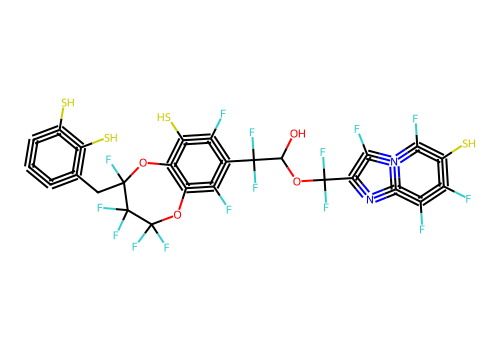

In [7]:
# Print exactly one molecule from the dataset using RDKit (append at end)
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw
from IPython.display import display

# Silence RDKit logs for this visualization-only conversion
RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')

# Common ZINC-style atom mapping when node features are categorical indices
ATOM_IDX_TO_NUM = {
    0: 6,   # C
    1: 7,   # N
    2: 8,   # O
    3: 9,   # F
    4: 15,  # P
    5: 16,  # S
    6: 17,  # Cl
    7: 35,  # Br
    8: 53,  # I
}
VALID_ATOMIC_NUMS = set(ATOM_IDX_TO_NUM.values())
BOND_IDX_TO_TYPE = {
    0: Chem.BondType.SINGLE,
    1: Chem.BondType.SINGLE,
    2: Chem.BondType.DOUBLE,
    3: Chem.BondType.TRIPLE,
    4: Chem.BondType.AROMATIC,
}

def _to_int_node_type(x_row):
    if x_row.dim() == 0:
        return int(x_row.item())
    if x_row.numel() == 1:
        return int(x_row.view(-1)[0].item())
    return int(x_row.argmax().item())

def _atomic_num_from_node_type(node_type):
    if node_type in ATOM_IDX_TO_NUM:
        return ATOM_IDX_TO_NUM[node_type]
    if node_type in VALID_ATOMIC_NUMS:
        return node_type
    return 6

def _bond_type_from_edge_attr(edge_attr, edge_id):
    if edge_attr is None:
        return Chem.BondType.SINGLE
    ea = edge_attr[edge_id]
    if ea.dim() == 0:
        bond_idx = int(ea.item())
    elif ea.numel() == 1:
        bond_idx = int(ea.view(-1)[0].item())
    else:
        bond_idx = int(ea.argmax().item())
    return BOND_IDX_TO_TYPE.get(bond_idx, Chem.BondType.SINGLE)

def pyg_data_to_rdkit_mol(data):
    mol = Chem.RWMol()

    node_to_idx = {}
    for n in range(data.num_nodes):
        node_type = _to_int_node_type(data.x[n])
        atomic_num = _atomic_num_from_node_type(node_type)
        atom_idx = mol.AddAtom(Chem.Atom(atomic_num))
        node_to_idx[n] = atom_idx

    edge_index = data.edge_index
    added = set()
    for e in range(edge_index.size(1)):
        u = int(edge_index[0, e])
        v = int(edge_index[1, e])
        if u == v:
            continue
        key = tuple(sorted((u, v)))
        if key in added:
            continue
        bond_type = _bond_type_from_edge_attr(getattr(data, 'edge_attr', None), e)
        mol.AddBond(node_to_idx[u], node_to_idx[v], bond_type)
        added.add(key)

    mol = mol.GetMol()
    mol.UpdatePropertyCache(strict=False)
    return mol

# ---- draw exactly one molecule ----
if 'dataset' not in locals():
    print("`dataset` not found. Run the dataset loading cell first.")
else:
    mol_index = 0
    sample = dataset[mol_index]
    mol = pyg_data_to_rdkit_mol(sample)
    print(f"Showing molecule index: {mol_index}")
    if hasattr(sample, 'y') and sample.y is not None:
        print(f"Label: {sample.y.item()}")
    display(Draw.MolToImage(mol, size=(500, 350)))

## Fidelity Studies for Di-Halo-Benzene Dataset

* **Fidelity+ (Masking the Motif via Atom Mutation):** We take the top $k$ nodes identified by the explainer and chemically neutralize them by mutating their features to Carbon atoms. Topology remains fully intact, checking if the removal of specific 9-class chemical signatures reduces model confidence without causing OOD topological shock.
* **Fidelity- (Isolating the Motif via Structural Dropping):** We isolate the identified core motif by dropping all other unimportant background ZINC nodes. Because a di-halo-benzene is a chemically stable graph alone, the residual motif can be safely passed to the frozen model without causing severe issues.

In [29]:
import torch
import numpy as np
import polars as pl
from torch_geometric.data import Data
from torch_geometric.utils import subgraph
from bcosgnn.explain_edge_attr import explain as explain_edge_attr

@torch.inference_mode()
def _get_pred_details(model, data, device):
    model.eval()
    d = data.to(device)
    batch = torch.zeros(d.num_nodes, dtype=torch.long, device=device)
    logits = model(d.x, d.edge_index, getattr(d, 'edge_attr', None), batch)
    logits = logits.flatten()
    pred_class = int(logits.argmax().item())
    probs = torch.softmax(logits, dim=0)
    p_orig = probs[pred_class].item()
    return pred_class, float(p_orig)

@torch.inference_mode()
def _class_prob(model, data, target_class, device):
    model.eval()
    d = data.to(device)
    batch = torch.zeros(d.num_nodes, dtype=torch.long, device=device)
    logits = model(d.x, d.edge_index, getattr(d, 'edge_attr', None), batch)
    logits = logits.flatten()
    probs = torch.softmax(logits, dim=0)
    return float(probs[target_class].item())

def drop_isolated_nodes(data, nodes_to_keep):
    """Fidelity- : Keep top k, drop background structurally."""
    if nodes_to_keep.numel() == 0:
        out = Data(
            x=torch.zeros((0, data.x.size(1)) if data.x.dim() > 1 else (0,), dtype=data.x.dtype),
            edge_index=torch.zeros((2, 0), dtype=torch.long),
            y=data.y.clone() if hasattr(data, 'y') else None
        )
        if hasattr(data, 'edge_attr') and data.edge_attr is not None:
            out.edge_attr = torch.zeros((0, data.edge_attr.size(1)) if data.edge_attr.dim() > 1 else (0,), dtype=data.edge_attr.dtype)
        return out
        
    edge_index, edge_attr = subgraph(
        subset=nodes_to_keep,
        edge_index=data.edge_index.cpu(),
        edge_attr=getattr(data, 'edge_attr', None),
        relabel_nodes=True,
        num_nodes=data.num_nodes
    )
    
    x_new = data.x.cpu()[nodes_to_keep]
    return Data(x=x_new, edge_index=edge_index, edge_attr=edge_attr, y=data.y.clone() if hasattr(data, 'y') else None)

def mutate_nodes_to_carbon(data, nodes_to_mutate):
    """Fidelity+ : Mutate top k atom features to Carbon (Idx 0) naturally."""
    d = data.clone()
    d.x = d.x.clone().cpu()
    for n in nodes_to_mutate:
        if d.x.dim() == 1:
            d.x[n] = 0
        else:
            d.x[n] = 0.0
            d.x[n, 0] = 1.0  # Assumes 0 index is Carbon
    return d

def fidelity_di_halo_single_graph(model, data, *, k=5, device):
    d = data.clone()
    pred_class, p_orig = _get_pred_details(model, d, device)

    # Explain the predicted class
    d_for_explain = d.to(device)
    batch = torch.zeros(d_for_explain.num_nodes, dtype=torch.long, device=device)
    contrib = explain_edge_attr(model, d_for_explain.x, d_for_explain.edge_index, getattr(d_for_explain, 'edge_attr', None), batch, target=pred_class)
    
    # Calculate node contribution scores
    # Take absolute sum of the incoming explainer edge attribution features per node.
    scores = contrib['x'].abs().sum(dim=-1).detach().cpu()
    
    k_eff = min(k, int(scores.numel()))
    if k_eff <= 0:
        important_nodes = torch.empty(0, dtype=torch.long)
    else:
        important_nodes = torch.topk(scores, k=k_eff, largest=True).indices
        
    all_nodes = torch.arange(d.num_nodes, dtype=torch.long)
    unimportant_nodes = all_nodes[~torch.isin(all_nodes, important_nodes)]
    
    # Fidelity+ (Mutate most important motifs/signatures to Carbon)
    d_mutated = mutate_nodes_to_carbon(d, important_nodes)
    p_mutated = _class_prob(model, d_mutated, pred_class, device)
    
    # Fidelity- (Isolate remaining top-k motif features structurally)
    d_isolated = drop_isolated_nodes(d, important_nodes)
    if d_isolated.num_nodes == 0:
        # Default empty graph prior => usually 1 / num_classes
        p_isolated = 1.0 / 9.0 
    else:
        p_isolated = _class_prob(model, d_isolated, pred_class, device)
        
    fid_plus = p_orig - p_mutated
    fid_minus = p_orig - p_isolated
    
    return {
        'pred_class': int(pred_class),
        'p_orig': float(p_orig),
        'p_mutated': float(p_mutated),
        'p_isolated': float(p_isolated),
        'fidelity_plus': float(fid_plus),
        'fidelity_minus': float(fid_minus),
        'k': k_eff,
        'num_nodes': int(d.num_nodes)
    }

def run_fidelity_study_di_halo(model, dataset, *, k=5, device=DEVICE, only_correct_preds=True):
    rows = []
    
    for i, raw in enumerate(dataset):
        d = raw.clone()
        pred_class, _ = _get_pred_details(model, d, device)
        y = int(d.y.item()) if hasattr(d, 'y') and d.y is not None else -1
        
        if only_correct_preds and y >= 0 and pred_class != y:
            continue
            
        rec = fidelity_di_halo_single_graph(model, d, k=k, device=device)
        rec['graph_id'] = i
        rec['label'] = y
        rec['is_correct'] = int(pred_class == y) if y >= 0 else 1
        rows.append(rec)
        
    df = pl.DataFrame(rows) if rows else pl.DataFrame([])
    
    if len(rows) > 0:
        summary = {
            'Graphs Analyzed': int(len(rows)),
            'K (Motif Size)': int(k),
            'Fidelity+ (Mean)': float(df['fidelity_plus'].mean()),
            'Fidelity+ (Std)': float(df['fidelity_plus'].std()) if len(rows) > 1 else float('nan'),
            'Fidelity- (Mean)': float(df['fidelity_minus'].mean()),
            'Fidelity- (Std)': float(df['fidelity_minus'].std()) if len(rows) > 1 else float('nan'),
            'Original Confidence': float(df['p_orig'].mean()),
            'Confidence after Mutation (F+)': float(df['p_mutated'].mean()),
            'Confidence after Isolation (F-)': float(df['p_isolated'].mean()),
        }
    else:
        summary = {}
        
    return df, pl.DataFrame([summary]) if summary else pl.DataFrame()

# ----- Execution (Assumes `final_model` and `test_ds` exist from prior cells) -----
# We set K=8 roughly as 8 nodes structure the di-halo-benzene (6 carbon + 2 halogens)
# Tweak as necessary.
if 'final_model' in locals() and 'test_ds' in locals():
    print("Running Mutational Fidelity Analysis...")
    df_dihalo_fid, df_dihalo_fid_summary = run_fidelity_study_di_halo(
        final_model, 
        test_ds[:200],  # Using a subset for faster demonstration
        k=8,  
        device=DEVICE,
        only_correct_preds=True
    )
    
    print('Analyzed Graphs:', len(df_dihalo_fid))
    display(df_dihalo_fid_summary)


Running Mutational Fidelity Analysis...
Analyzed Graphs: 200
Analyzed Graphs: 200


Graphs Analyzed,K (Motif Size),Fidelity+ (Mean),Fidelity+ (Std),Fidelity- (Mean),Fidelity- (Std),Original Confidence,Confidence after Mutation (F+),Confidence after Isolation (F-)
i64,i64,f64,f64,f64,f64,f64,f64,f64
200,8,0.617892,0.484596,0.368364,0.47229,1.0,0.382108,0.631636


In [ ]:
class_names = {
    0: "ortho-F",
    1: "meta-F",
    2: "para-F",
    3: "ortho-Cl",
    4: "meta-Cl",
    5: "para-Cl",
    6: "ortho-Br",
    7: "meta-Br",
    8: "para-Br",
}

str_class_names = {str(k): v for k, v in class_names.items()}

df_per_class_summary = (
    df_dihalo_fid.group_by("label")
    .agg([
        pl.len().alias("n_graphs"),
        pl.col("fidelity_plus").mean().alias("f_plus_mean"),
        pl.col("fidelity_plus").std().alias("f_plus_std"),
        pl.col("fidelity_minus").mean().alias("f_minus_mean"),
        pl.col("fidelity_minus").std().alias("f_minus_std"),
        pl.col("p_mutated").mean().alias("p_mutated_mean"),
        pl.col("p_isolated").mean().alias("p_isolated_mean"),
        pl.col("p_orig").mean().alias("p_orig_mean")
    ])
    .with_columns(
        pl.col("label").cast(pl.String).replace(str_class_names).alias("Isomer Class")
    )
    .sort("label") 
    .select(["Isomer Class", "label", "n_graphs", "f_plus_mean", "f_plus_std", "f_minus_mean", "f_minus_std", "p_mutated_mean", "p_isolated_mean", "p_orig_mean"])
)

display(df_per_class_summary)

Isomer Class,label,n_graphs,f_plus_mean,f_plus_std,f_minus_mean,f_minus_std,p_mutated_mean,p_isolated_mean,p_orig_mean
str,i64,u32,f64,f64,f64,f64,f64,f64,f64
"""ortho-F""",0,23,0.999897,0.000151,0.002813,0.012961,0.000103,0.997187,1.0
"""meta-F""",1,23,0.999999,0.000001,0.137049,0.23867,4.8205e-30,0.86295,0.999999
"""para-F""",2,16,0.56252,0.512323,0.999999,0.000003,0.43748,8.5219e-23,0.999999
"""ortho-Cl""",3,31,0.00036,0.000758,0.274191,0.431901,0.999639,0.725808,0.999999
"""meta-Cl""",4,20,0.999139,0.002666,0.197761,0.405799,0.00086,0.802238,0.999999
"""para-Cl""",5,21,3.9736e-8,1.8210e-7,1.0,2.6014e-8,1.0,0.0,1.0
"""ortho-Br""",6,25,1.0,3.8958e-12,4.7684e-9,2.3842e-8,4.0040e-12,1.0,1.0
"""meta-Br""",7,19,0.083502,0.235297,0.000041,0.000176,0.916498,0.999959,1.0
"""para-Br""",8,22,1.0,0.0,0.954546,0.2132,2.3967e-19,0.045454,1.0
